<a href="https://colab.research.google.com/github/ranjanchoubey/FedArtML/blob/main/examples/13_Get_started_create_FL_data_label_skew_dirichlet_EdgeIIoTset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 📑 Table of Contents

- [Getting started with FedArtML creating FL data (label skew) and implementing an FL model](#getting-started-with-fedartml-creating-fl-data-label-skew-and-implementing-an-fl-model)
- [Install libraries](#install-libraries)
- [Import libraries](#import-libraries)
- [Define parameters](#define-parameters)
  - [📁 Reproducibility Notes](#reproducibility-notes)
- [Define Functions & Model Architectures](#define-functions-model-architectures)
- [Load and preprocess Edge-IIoTset data](#load-and-preprocess-edge-iiotset-data)
- [Create the federated dataset](#create-the-federated-dataset)
- [Train and Compare All Models](#train-and-compare-all-models)
- [Experiment 2: Balanced Data, No Rebalancing](#experiment-2-balanced-data-no-rebalancing)
- [Experiment 3: Unbalanced Data + Full Fed-IDS Improvements](#experiment-3-unbalanced-data-full-fed-ids-improvements)
  - [🔬 Comparison 1 — Unbalanced vs Balanced (No Rebalancing)](#comparison-1-unbalanced-vs-balanced-no-rebalancing)
  - [🔬 Comparison 2 — Unbalanced Baseline vs Full Fed-IDS Improvements](#comparison-2-unbalanced-baseline-vs-full-fed-ids-improvements)
  - [⚠️ Convergence Caveats](#convergence-caveats)
  - [📊 Final Comparison Report](#final-comparison-report)

# Getting started with FedArtML creating FL data (label skew) and implementing an FL model

Our ***FedArTML*** tool facilitates the generation of non-IID datasets
in a controlled way to support federated learning (FL) research for federated datasets from centralized datasets. It includes classes and functions to create federated datasets from centralized data, given the **number** of **clients** and the degree of heterogeneity (**non-IID-ness**) desired.

This guide aims to **understand** using the **SplitAsFederatedData** class to create federated datasets with the **Dirichlet method** for **Label skew**. We use the `Edge-IIoTset` dataset for our tests. Moreover, we include the `Flower framework` to train an FL model using the output from the FedArtML library.

This notebook implements the **DeepFed** CNN-GRU architecture from *Li et al., IEEE Transactions on Industrial Informatics, 2021*.

**Notes:**
1. To check the source code, you can visit the [GitHub repo](https://github.com/Sapienza-University-Rome/FedArtML)
2. To check the documentation, you visit the [dedicated link](https://fedartml.readthedocs.io/en/latest/)

# Install libraries

First, installing the FedArtML and Flower libraries from Pypi (the latest version) is necessary.

In [1]:
#@title Install Dependencies { display-mode: "form" }
!pip install -q fedartml flwr[simulation] jax jaxlib keras

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.14/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

# Import libraries

In [2]:
#@title Import Libraries & Configure Environment { display-mode: "form" }

import os
os.environ["KERAS_BACKEND"] = "jax"
# Force all JAX/Keras work onto the NVIDIA GPU. Pre-allocation is disabled to
# avoid cuSolver handle exhaustion when Flower spawns many short-lived Ray
# actors; the GPU is still used for every training and evaluation step.
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.30"
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=0"
# Persistent JAX/XLA compilation cache: reuse compiled kernels across the many
# short-lived Ray client actors Flower spawns, instead of recompiling each task.
os.environ["JAX_COMPILATION_CACHE_DIR"] = os.path.expanduser("~/.cache/jax_fl_cache")
os.environ["JAX_PERSISTENT_CACHE_MIN_COMPILE_TIME_SECS"] = "0"
os.environ["JAX_PERSISTENT_CACHE_MIN_ENTRY_SIZE_BYTES"] = "-1"

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import numpy as np
import sys
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

import jax
import keras
from keras.models import Model
from keras.losses import SparseCategoricalCrossentropy
from keras.metrics import SparseCategoricalAccuracy
from keras.optimizers import Adam
from keras import losses as losses_mod, metrics as metrics_mod
from keras import layers, models, losses as losses_mod, metrics as metrics_mod, optimizers

import time
import pickle

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns
sns.set(style="darkgrid", rc = {'figure.figsize':(5,7)})

from sklearn.impute import SimpleImputer

import plotly.graph_objects as go


# Garbage Collector - use it like gc.collect()
import gc

# Custom Callback To Include in Callbacks List At Training Time
class GarbageCollectorCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()

from fedartml import InteractivePlots, SplitAsFederatedData

import flwr as fl

from typing import List, Tuple, Dict, Optional
from flwr.common import Metrics

# ================================================================================
# GPU DEVICE CONFIGURATION - JAX Backend
# ================================================================================
print("\n" + "="*80)
print("DEVICE CONFIGURATION - JAX BACKEND")
print("="*80)

# Check for device availability via JAX
jax_devices = jax.devices()
has_gpu = any(str(d).startswith('gpu') or 'cuda' in str(d).lower() for d in jax_devices)

if has_gpu:
    print(f"\n✓ JAX GPU(s) Detected: {len(jax_devices)}")
    for d in jax_devices:
        print(f"  - {d}")
    device_type = "GPU"
else:
    print(f"\n⚠ No GPU found - JAX running on CPU")
    for d in jax_devices:
        print(f"  - {d}")
    device_type = "CPU"

print(f"\n✓ Selected Device: {device_type}")
print(f"✓ Keras Backend: {keras.backend.backend()}")
print(f"✓ Keras Version: {keras.__version__}")
print("="*80 + "\n")

print("✓ All libraries imported successfully!")


DEVICE CONFIGURATION - JAX BACKEND



✓ JAX GPU(s) Detected: 1
  - cuda:0

✓ Selected Device: GPU
✓ Keras Backend: jax
✓ Keras Version: 3.16.0

✓ All libraries imported successfully!


# Define parameters

Then it is necessary to define some parameters to run this notebook smoothly. The most important are:



*   `local_nodes_glob`: Defines the desired number of clients (local nodes) the centralized data will be divided into. In this case, we set it as 3.
*   `Alpha`: Using the "Dirichlet-based" method, we need to define the `Alpha`, which will determine the degree of heterogeneity of the client's distribution (non-IID-ness). Notice that the smaller the value of `Alpha`, the higher the non-IID-ness. In this case, we set it as 1. Those parameters can be changed if desired to get familiar with their use.

In [3]:
#@title Initialization { display-mode: "form" }

# Define random state for reproducibility
random_state = 0  # @param {type: "integer", min: 0, max: 10000, step: 1}

# Define colors to use in plots
colors = ["#00cfcc","#e6013b","#007f88","#00cccd","#69e0da","darkblue","#FFFFFF"]

# Local dataset path
dataset_path = 'data/raw'
print("Running locally — using relative paths")

csv_filename = 'DNN-EdgeIIoT-dataset.csv'

# Sampling for faster execution (None = full dataset)
MAX_SAMPLES = 100_000  # @param {type: "integer"}

print("\n✓ Initialization complete. Load data and then configure federated learning parameters.")

Running locally — using relative paths

✓ Initialization complete. Load data and then configure federated learning parameters.


## 📁 Reproducibility Notes

- **Clients:** `num_clients = 6` local nodes (see *FEDERATED LEARNING CONFIGURATION*).
- **Data split:** Dirichlet label-skew with `alpha = 0.001` (highly non-IID). The **Unbalanced** split uses `without_class_completion` (clients may be missing classes); the **Balanced** split reuses the same Dirichlet draw with `with_class_completion` so every client has at least one sample of every class.
- **FL rounds:** `comms_round = 5` communication rounds.
- **Local training:** `epochs = 3` local epochs per client per round, batch size `BATCH_SIZE = 512`.
- **GPU memory:** `XLA_PYTHON_CLIENT_PREALLOCATE=false`, `XLA_PYTHON_CLIENT_MEM_FRACTION=0.85`, `XLA_FLAGS=--xla_gpu_autotune_level=0` — pre-allocation is disabled to avoid cuSolver handle exhaustion when Flower/Ray spawns many short-lived client actors.
- **Random state:** `random_state = 0` for the federated split; the Full Fed-IDS experiment additionally seeds each client via `seed + cid * 1000`.
- **Dataset:** Edge-IIoTset, 15 attack/benign classes, `MAX_SAMPLES = 100_000` sampled for faster execution.

# Define Functions & Model Architectures

For the sake of order, we defined some functions that will be used in this guide.

In [4]:
#@title Define Helper Functions & Models { display-mode: "form" }

# ---------- Helpers ----------

BATCH_SIZE = 64

def test_model(model, X_test, Y_test):
    cce = keras.losses.SparseCategoricalCrossentropy(from_logits=False)
    logits = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(logits, axis=1)
    loss = float(np.array(cce(Y_test, logits)))
    acc = accuracy_score(y_pred, Y_test)
    bacc = balanced_accuracy_score(Y_test, y_pred)
    pre = precision_score(y_pred, Y_test, average='weighted', zero_division=0)
    rec = recall_score(y_pred, Y_test, average='weighted', zero_division=0)
    f1s = f1_score(y_pred, Y_test, average='weighted', zero_division=0)
    f1_macro = f1_score(y_pred, Y_test, average='macro', zero_division=0)
    return loss, acc, bacc, pre, rec, f1s, f1_macro

def from_FedArtML_to_Flower_format(clients_dict):
    list_x_train, list_y_train = [], []
    for client in clients_dict.keys():
        each_client_train = np.array(clients_dict[client], dtype=object)
        feat = np.array([row for row in each_client_train[:, 0]])
        y_tra = np.array(each_client_train[:, 1], dtype=int)
        list_x_train.append(feat)
        list_y_train.append(y_tra)
    return list_x_train, list_y_train

def retrieve_global_metrics(hist, metric_type, metric, best_metric):
    metric_dict = hist.metrics_centralized if metric_type == "centralized" else hist.metrics_distributed
    rounds, values = zip(*metric_dict[metric])
    return max(values) if best_metric else values[-1]

class FlowerClient(fl.client.NumPyClient):
    def __init__(self, model, x_train, y_train, x_test, y_test, epochs_client):
        self.model = model
        self.x_train, self.y_train = x_train, y_train
        self.x_test, self.y_test = x_test, y_test
        self.epochs_client = epochs_client

    def get_parameters(self, config):
        return self.model.get_weights()

    def fit(self, parameters, config):
        self.model.set_weights(parameters)
        self.model.fit(self.x_train, self.y_train.astype(int),
                       epochs=self.epochs_client,
                       batch_size=BATCH_SIZE, verbose=0)
        return self.model.get_weights(), len(self.x_train), {}

    def evaluate(self, parameters, config):
        self.model.set_weights(parameters)
        loss, acc = self.model.evaluate(self.x_test, self.y_test.astype(int),
                                        batch_size=BATCH_SIZE, verbose=0)
        return loss, len(self.x_test), {"accuracy": acc}


# ---------- Full Fed-IDS helpers ----------

def _softmax_np(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / np.sum(e, axis=-1, keepdims=True)


def prepare_balanced_augmented_data(x, y, num_deviations=2000, degree=1.0, seed=0, max_oversample=5000):
    """
    BalanceFL-style local preprocessing used in the paper:
      1) Balanced sampling: oversample every class up to the size of the largest class
         (capped at max_oversample to keep local training feasible on a 6 GB GPU).
      2) Feature-space augmentation: per-class covariance -> weighted-average covariance
         -> multivariate-Gaussian deviations applied with probability
         (target_count - class_count) / target_count.

    SIMPLIFICATION vs. the paper (documented honestly): the paper applies this
    covariance-based augmentation to *learned penultimate-layer feature embeddings*
    extracted by each model's feature sub-network. To avoid a full custom
    per-architecture training loop across the 4 different network types
    (DNN / CNN+GRU / CNN+LSTM / Transformer) in this demo notebook, we instead
    augment the *raw standardized input features* directly. This is an
    approximation, not an exact reproduction of the paper's embedding-space
    augmentation.
    """
    if x is None or len(x) == 0:
        return x, y

    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=int)
    classes, counts = np.unique(y, return_counts=True)
    max_count = int(counts.max())
    target_count = min(max_count, max_oversample)
    rng = np.random.default_rng(seed)

    # ---- Balanced oversampling ----
    balanced_x, balanced_y = [], []
    for c, count in zip(classes, counts):
        idx = np.where(y == c)[0]
        repeat = target_count // count
        rem = target_count % count
        extended = np.tile(idx, repeat)
        if rem > 0:
            extra = rng.choice(idx, size=rem, replace=False)
            extended = np.concatenate([extended, extra])
        balanced_x.append(x[extended])
        balanced_y.append(y[extended])

    x_bal = np.concatenate(balanced_x)
    y_bal = np.concatenate(balanced_y)

    # ---- Covariance-based feature-space augmentation ----
    orig_shape = x.shape
    d = int(np.prod(orig_shape[1:]))
    x2d = x.reshape(x.shape[0], d).astype(np.float64)

    covs, weights = [], []
    for c, count in zip(classes, counts):
        xc = x2d[y == c]
        if len(xc) > 1:
            cov = np.cov(xc, rowvar=False)
        else:
            cov = np.zeros((d, d), dtype=np.float64)
        covs.append(cov)
        weights.append(float(count))

    avg_cov = np.average(covs, axis=0, weights=np.array(weights)).astype(np.float64)
    jitter = 1e-5 * np.trace(avg_cov) / max(1, d)
    avg_cov += np.eye(d) * jitter

    try:
        devs = rng.multivariate_normal(mean=np.zeros(d), cov=avg_cov, size=num_deviations)
    except Exception:
        var = np.maximum(np.diag(avg_cov), 1e-8)
        devs = rng.normal(0.0, np.sqrt(var), size=(num_deviations, d))
    devs = devs.astype(np.float32)

    # Vectorized augmentation: per-class probability LUT, then apply Gaussian
    # deviations to a random subset of rows in one shot (replaces the per-sample
    # Python loop). RNG consumption order differs from the old loop but the
    # sampling distribution is identical.
    prob_lut = np.zeros(int(classes.max()) + 1, dtype=np.float32)
    for c, count in zip(classes, counts):
        prob_lut[int(c)] = (target_count - count) / target_count
    mask = rng.random(len(x_bal)) < prob_lut[y_bal]
    dev_idx = rng.integers(0, num_deviations, size=int(mask.sum()))
    x_aug = x_bal.reshape(len(x_bal), d).copy()
    x_aug[mask] += degree * devs[dev_idx]
    x_aug = x_aug.reshape((-1, *orig_shape[1:]))

    perm = rng.permutation(len(x_aug))
    return x_aug[perm], y_bal[perm]


def compute_c_neg_mask(y_train, num_classes):
    """Multi-hot vector of length num_classes: 1.0 for classes ABSENT from this
    client's true (pre-augmentation) labels, 0.0 for classes that are present.
    Oversampling never introduces new classes, so this is unambiguous."""
    present = np.unique(np.asarray(y_train, dtype=int).ravel())
    mask = np.ones(num_classes, dtype=np.float32)
    mask[present] = 0.0
    return mask


def prepare_fedids_client_data(x_train, y_train, num_classes, seed=0):
    """Precompute a FedIDS client's balanced+augmented shard plus the two
    per-client constants the paper loss / FedAvg weighting need:
      - n_true    : the client's REAL sample count BEFORE oversampling (used as
                    the FedAvg weight n_k, matching the paper's weighted average)
      - c_neg_mask: absent-class mask (see compute_c_neg_mask)
    Deterministic in `seed`, so it is safe to compute this ONCE per client on the
    driver and reuse it across every Flower fit/evaluate task.
    """
    n_true = int(len(x_train))
    c_neg_mask = compute_c_neg_mask(y_train, num_classes)
    x_aug, y_aug = prepare_balanced_augmented_data(x_train, y_train, seed=seed)
    return x_aug, y_aug, n_true, c_neg_mask


class FedIDSClient(fl.client.NumPyClient):
    """
    Flower client implementing the full paper improvements:
      - Balanced local sampling + covariance-based feature-space augmentation
      - Knowledge distillation from the server (teacher) model, restricted to
        classes ABSENT from this client (paper Eq. 2)
      - Smooth regularization (negative entropy) on PRESENT classes (paper Eq. 7)
    All three terms are delivered to Keras through a packed label
    [hard | teacher_soft | c_neg], consumed by make_fedids_paper_loss.
    """
    def __init__(self, model, x_train, y_train, x_test, y_test, epochs_client,
                 num_classes, seed=0, temperature=2.0, precomputed=None):
        self.model = model
        if precomputed is not None:
            # Driver-precomputed (x_aug, y_aug, n_true, c_neg_mask) - no recompute.
            self.x_train, self.y_train, self.n_true, self.c_neg_mask = precomputed
        else:
            self.x_train, self.y_train, self.n_true, self.c_neg_mask = \
                prepare_fedids_client_data(x_train, y_train, num_classes, seed=seed)
        self.x_test, self.y_test = x_test, y_test
        self.epochs_client = epochs_client
        self.num_classes = num_classes
        self.temperature = temperature
        print(f"  FedIDS client ready: {len(self.x_train)} balanced+augmented samples "
              f"(n_true={self.n_true}), {self.num_classes} classes, T={temperature}, "
              f"absent classes={int(self.c_neg_mask.sum())}")

    def get_parameters(self, config):
        return self.model.get_weights()

    def fit(self, parameters, config):
        # 1) Start from the server (teacher) model.
        self.model.set_weights(parameters)

        # 2) Teacher soft targets via temperature scaling (paper Eq. 1):
        #    softmax(log(p)/T) == p^(1/T) / sum(p^(1/T)).
        teacher_probs = self.model.predict(self.x_train, batch_size=BATCH_SIZE, verbose=0)
        teacher_logits = np.log(np.asarray(teacher_probs) + 1e-8)
        teacher_soft = _softmax_np(teacher_logits / self.temperature).astype(np.float32)

        # 3) Build packed target [hard one-hot | teacher_soft | c_neg mask].
        y_int = self.y_train.astype(int).ravel()
        n = len(y_int)
        y_onehot = np.zeros((n, self.num_classes), dtype=np.float32)
        y_onehot[np.arange(n), y_int] = 1.0
        c_neg_broadcast = np.tile(self.c_neg_mask.astype(np.float32), (n, 1))
        y_packed = np.concatenate([y_onehot, teacher_soft, c_neg_broadcast], axis=-1)

        # 4) Local training with the paper composite loss (compiled into the model).
        self.model.fit(self.x_train, y_packed,
                       epochs=self.epochs_client,
                       batch_size=BATCH_SIZE,
                       verbose=0)
        # FedAvg weight = TRUE original sample count, not the oversampled count.
        return self.model.get_weights(), self.n_true, {}

    def evaluate(self, parameters, config):
        self.model.set_weights(parameters)
        loss, acc, bacc, pre, rec, f1s, f1_macro = test_model(self.model, self.x_test, self.y_test)
        return loss, len(self.x_test), {"accuracy": acc, "balanced_accuracy": bacc,
                                        "precision": pre, "recall": rec,
                                        "f1score": f1s, "f1_macro": f1_macro}


def make_fedids_paper_loss(num_classes, temperature, lambda1):
    """Paper Fed-IDS composite loss over a packed target
    y_packed = [hard one-hot | teacher_soft | c_neg mask] (width 3*num_classes):
      - hard-label cross-entropy (Eq. 6),
      - knowledge distillation restricted to ABSENT classes (Eq. 2),
      - smooth regularization (negative entropy) on PRESENT classes (Eq. 7).
    """
    def loss_fn(y_packed, y_pred):
        y_true = y_packed[:, :num_classes]
        teacher_soft = y_packed[:, num_classes:2 * num_classes]
        c_neg_mask = y_packed[:, 2 * num_classes:3 * num_classes]
        c_pos_mask = 1.0 - c_neg_mask
        # Hard-label cross-entropy (Eq. 6) - one-hot already zeroes out non-true
        # classes, so this is inherently restricted to the true (C_pos) class.
        ce = -keras.ops.sum(y_true * keras.ops.log(y_pred + 1e-8), axis=-1)
        # Student temperature-scaled soft prediction, same transform as teacher (Eq. 1).
        student_soft = keras.ops.power(y_pred + 1e-8, 1.0 / temperature)
        student_soft = student_soft / keras.ops.sum(student_soft, axis=-1, keepdims=True)
        # Knowledge-distillation loss restricted to absent classes only (Eq. 2).
        kd = -keras.ops.sum(c_neg_mask * teacher_soft * keras.ops.log(student_soft + 1e-8), axis=-1)
        # Smooth regularization: negative entropy on present classes only (Eq. 7).
        smooth = keras.ops.sum(c_pos_mask * y_pred * keras.ops.log(y_pred + 1e-8), axis=-1)
        return ce + kd + lambda1 * smooth
    return loss_fn


def make_fedids_model(builder, input_shape, num_classes, lambda1=1.0, temperature=2.0):
    """Wrap any architecture with the paper Fed-IDS composite loss.

    The loss consumes a packed target [hard | teacher_soft | c_neg] built by
    FedIDSClient.fit; `temperature` must match the client's teacher-softening
    temperature. Metrics are dropped from compile() because CategoricalAccuracy
    cannot compare a (3*num_classes)-wide packed target against predictions -
    real evaluation happens separately via test_model() in evaluate_fn.
    (metrics=[] is required, not just omitted: Keras only clears a model's
    previously-compiled metrics when metrics is explicitly non-None, and the
    architecture builders above already compile with SparseCategoricalAccuracy,
    which would otherwise silently survive this recompile and crash on the
    packed target's width.)
    """
    model = builder(input_shape, num_classes)
    model.compile(optimizer=Adam(0.001),
                  loss=make_fedids_paper_loss(num_classes, temperature, lambda1),
                  metrics=[])
    return model


# ---------- Model Definitions ----------

def dnn_model(input_shape, num_classes):
    """Paper encoder-style DNN: hidden layers sized 75% / 50% / 25% of the input
    feature count, dropout 0.01, ReLU hidden activations, softmax output."""
    d = int(np.prod(input_shape))
    h1, h2, h3 = max(1, round(0.75 * d)), max(1, round(0.50 * d)), max(1, round(0.25 * d))
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(h1, activation='relu')(x)
    x = layers.Dense(h2, activation='relu')(x)
    x = layers.Dense(h3, activation='relu')(x)
    x = layers.Dropout(0.01)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                  loss=losses_mod.SparseCategoricalCrossentropy(),
                  metrics=[metrics_mod.SparseCategoricalAccuracy()])
    return model

def DeepFed_model(input_shape, num_classes):
    """DeepFed CNN-GRU (Li et al., IEEE TII 2021)."""
    inputs = layers.Input(shape=input_shape)
    # GRU branch
    gru = layers.GRU(32, return_sequences=True)(inputs)
    gru = layers.GRU(32)(gru)
    # CNN branch
    cnn = layers.Conv1D(16, 3, padding='same', activation='relu')(inputs)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.MaxPooling1D(2)(cnn)
    cnn = layers.Conv1D(32, 3, padding='same', activation='relu')(cnn)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.MaxPooling1D(2)(cnn)
    cnn = layers.Conv1D(64, 3, padding='same', activation='relu')(cnn)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.MaxPooling1D(2)(cnn)
    cnn = layers.Flatten()(cnn)
    # Fusion
    fusion = layers.Concatenate()([gru, cnn])
    x = layers.Dense(128, activation='relu')(fusion)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                  loss=losses_mod.SparseCategoricalCrossentropy(),
                  metrics=[metrics_mod.SparseCategoricalAccuracy()])
    return model

def cnn_lstm_model(input_shape, num_classes):
    """CNN+LSTM: DeepFed variant with LSTM instead of GRU."""
    inputs = layers.Input(shape=input_shape)
    # LSTM branch
    lstm = layers.LSTM(32, return_sequences=True)(inputs)
    lstm = layers.LSTM(32)(lstm)
    # CNN branch (same as DeepFed)
    cnn = layers.Conv1D(16, 3, padding='same', activation='relu')(inputs)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.MaxPooling1D(2)(cnn)
    cnn = layers.Conv1D(32, 3, padding='same', activation='relu')(cnn)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.MaxPooling1D(2)(cnn)
    cnn = layers.Conv1D(64, 3, padding='same', activation='relu')(cnn)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.MaxPooling1D(2)(cnn)
    cnn = layers.Flatten()(cnn)
    # Fusion
    fusion = layers.Concatenate()([lstm, cnn])
    x = layers.Dense(128, activation='relu')(fusion)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                  loss=losses_mod.SparseCategoricalCrossentropy(),
                  metrics=[metrics_mod.SparseCategoricalAccuracy()])
    return model

def transformer_model(input_shape, num_classes):
    """Lightweight Transformer for sequence classification."""
    inputs = layers.Input(shape=input_shape)
    # Embed to higher dim
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    # Transformer block
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)
    ff = layers.Dense(128, activation='relu')(x)
    ff = layers.Dense(64)(ff)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)
    # Pool and classify
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                  loss=losses_mod.SparseCategoricalCrossentropy(),
                  metrics=[metrics_mod.SparseCategoricalAccuracy()])
    return model

print("✓ All helper functions and 4 model architectures defined.")

✓ All helper functions and 4 model architectures defined.


# Load and preprocess Edge-IIoTset data

The Edge-IIoTset dataset consists of IoT/IIoT network traffic data with various features. We will load, preprocess, and split the data into training and test sets.

In [5]:
#@title Download Edge-IIoTset Dataset { display-mode: "form" }

import os
import shutil

csv_path = os.path.join(dataset_path, csv_filename)
os.makedirs(dataset_path, exist_ok=True)

df = None

# Option 1: Load from local path
if os.path.exists(csv_path):
    print(f"✓ Found local dataset: {csv_path}")
    df = pd.read_csv(csv_path, low_memory=False)

# Option 2: Download from Kaggle via kagglehub
if df is None:
    try:
        print("\nDownloading Edge-IIoTset from Kaggle (via kagglehub)...")
        import kagglehub
        downloaded_path = kagglehub.dataset_download(
            handle="mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot",
            path="Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
        )
        # Move to expected location
        shutil.copy(downloaded_path, csv_path)
        print(f"✓ Dataset downloaded to {csv_path}")
        df = pd.read_csv(csv_path, low_memory=False)
    except Exception as e:
        print(f"Download failed: {e}")
        print("\nPlease download manually from:")
        print("  https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot")
        print(f"  and place DNN-EdgeIIoT-dataset.csv in: {os.path.abspath(dataset_path)}")
        df = pd.DataFrame()

# Subsample for faster execution
if not df.empty and MAX_SAMPLES is not None and MAX_SAMPLES < len(df):
    df = df.sample(n=MAX_SAMPLES, random_state=random_state).reset_index(drop=True)
    print(f"\n✓ Subsampled to {MAX_SAMPLES} rows for faster execution")

# Display info
if not df.empty:
    print("\n" + "="*80)
    print("Edge-IIoTset Dataset Loaded Successfully!")
    print("="*80)
    print(f"Shape: {df.shape[0]} records x {df.shape[1]} features")
    print(f"\nColumn names ({len(df.columns)} total):")
    print(df.columns.tolist())

✓ Found local dataset: data/raw/DNN-EdgeIIoT-dataset.csv



✓ Subsampled to 100000 rows for faster execution

Edge-IIoTset Dataset Loaded Successfully!
Shape: 100000 records x 63 features

Column names (63 total):
['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum', 'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused', 'http.file_data', 'http.content_length', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack', 'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options', 'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream', 'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request', 'dns.retransmit_request_in', 'mqtt.conack.flags', 'mqtt.confl

In [6]:
#@title Preprocess Edge-IIoTset Data { display-mode: "form" }

# Preprocess Edge-IIoTset data
if df is not None and not df.empty:
    print("\n" + "="*80)
    print("Preprocessing Edge-IIoTset Data")
    print("="*80)

    print(f"\nDataFrame shape: {df.shape}")
    print(f"Column names (first 10): {list(df.columns[:10])}")

    # Edge-IIoTset has 'Attack_type' (multi-class) and 'Attack_label' (binary)
    # We use Attack_type for multi-class classification (closer to paper)
    if 'Attack_type' in df.columns:
        y_raw = df['Attack_type'].values
        print(f"\n✓ Found 'Attack_type' column")
        print(f"  Unique labels: {np.unique(y_raw)}")
        print(f"  Label counts: {pd.Series(y_raw).value_counts().to_dict()}")

        # Drop the label columns and non-numeric metadata columns
        drop_meta = ['Attack_label', 'Attack_type', 'frame.time', 'ip.src_host', 'ip.dst_host',
                     'arp.src.proto_ipv4', 'arp.dst.proto_ipv4', 'http.file_data',
                     'http.request.full_uri', 'icmp.transmit_timestamp', 'http.request.uri.query',
                     'tcp.options', 'tcp.payload', 'tcp.srcport', 'tcp.dstport', 'udp.port',
                     'mqtt.msg', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.protoname', 'mqtt.topic']
        X_df = df.drop(columns=[c for c in drop_meta if c in df.columns], errors='ignore')
    else:
        print("ERROR: 'Attack_type' column not found!")
        print(f"Available columns: {list(df.columns)}")
        raise ValueError("'Attack_type' column not found in dataset")

    # Select only numeric columns for features
    X_df = X_df.select_dtypes(include=[np.number])
    print(f"\nNumeric features shape: {X_df.shape}")
    print(f"Feature columns: {list(X_df.columns[:10])}... (showing first 10)")

    # Drop constant columns (zero variance, no predictive value)
    constant_cols = X_df.columns[X_df.nunique() <= 1].tolist()
    if constant_cols:
        X_df = X_df.drop(columns=constant_cols)
        print(f"\n✓ Dropped {len(constant_cols)} constant columns: {constant_cols}")
        print(f"  Final feature shape: {X_df.shape}")

    X = X_df.values

    # Convert labels to numeric
    unique_labels = sorted(set(y_raw))
    label_mapping = {label: idx for idx, label in enumerate(unique_labels)}
    y = np.array([label_mapping[label] for label in y_raw]).astype(int)

    print(f"\nLabel mapping ({len(label_mapping)} classes):")
    for label, idx in label_mapping.items():
        print(f"  {label} -> {idx}")

    print(f"\nLabel information:")
    print(f"  - Unique numeric labels: {sorted(np.unique(y))}")
    print(f"  - Label range: [{y.min()}, {y.max()}]")

    # Build reverse mapping once for efficiency
    reverse_label_mapping = {v: k for k, v in label_mapping.items()}

    # Check class distribution
    unique_classes, class_counts = np.unique(y, return_counts=True)
    print(f"\nOriginal class distribution:")
    for cls, count in zip(unique_classes, class_counts):
        original_label = reverse_label_mapping[cls]
        print(f"  Class {cls} ({original_label}): {count} samples ({100*count/len(y):.1f}%)")

    # Handle missing values in features
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)
    print("\n✓ Missing values handled (mean imputation)")

    # Normalize features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    print("✓ Features normalized (StandardScaler)")

    # Remove classes with very few samples (< 2) to avoid stratification issues
    min_samples_per_class = 2
    valid_classes = unique_classes[class_counts >= min_samples_per_class]
    mask = np.isin(y, valid_classes)
    X = X[mask]
    y = y[mask]

    print(f"\nFiltered class distribution (removed classes with < {min_samples_per_class} samples):")
    unique_classes, class_counts = np.unique(y, return_counts=True)
    for cls, count in zip(unique_classes, class_counts):
        original_label = reverse_label_mapping[cls]
        print(f"  Class {cls} ({original_label}): {count} samples ({100*count/len(y):.1f}%)")

    # Reshape for DeepFed: (samples, features) -> (samples, seq_len, 1)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    print(f"✓ Reshaped for DeepFed: {X.shape}")

    # Split into train and test sets
    try:
        x_train_glob, x_test_glob, y_train_glob, y_test_glob = train_test_split(
            X, y, test_size=0.2, random_state=random_state, stratify=y
        )
        print("\n✓ Used stratified train-test split")
    except ValueError:
        x_train_glob, x_test_glob, y_train_glob, y_test_glob = train_test_split(
            X, y, test_size=0.2, random_state=random_state, stratify=None
        )
        print("✓ Used random train-test split (stratification not possible)")

    # Get dataset statistics
    num_classes = len(np.unique(y_train_glob))
    input_shape = x_train_glob.shape[1:]

    print(f"\nDataset Statistics:")
    print(f"  - Training set: {x_train_glob.shape}")
    print(f"  - Test set: {x_test_glob.shape}")
    print(f"  - Number of classes: {num_classes}")
    print(f"  - Input shape: {input_shape}")
    print(f"  - Label range (train): [{y_train_glob.min()}, {y_train_glob.max()}]")
    print(f"  - Label range (test): [{y_test_glob.min()}, {y_test_glob.max()}]")
    print(f"\nClass distribution in training set:")
    unique, counts = np.unique(y_train_glob, return_counts=True)
    for cls, count in zip(unique, counts):
        pct = 100 * count / len(y_train_glob)
        original_label = reverse_label_mapping[cls]
        print(f"    Class {cls} ({original_label}): {count} samples ({pct:.1f}%)")
else:
    print("Cannot preprocess - dataset not loaded")
    x_train_glob = x_test_glob = y_train_glob = y_test_glob = None
    num_classes = input_shape = None


Preprocessing Edge-IIoTset Data

DataFrame shape: (100000, 63)
Column names (first 10): ['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum', 'icmp.seq_le', 'icmp.transmit_timestamp']

✓ Found 'Attack_type' column
  Unique labels: ['Backdoor' 'DDoS_HTTP' 'DDoS_ICMP' 'DDoS_TCP' 'DDoS_UDP' 'Fingerprinting'
 'MITM' 'Normal' 'Password' 'Port_Scanning' 'Ransomware' 'SQL_injection'
 'Uploading' 'Vulnerability_scanner' 'XSS']
  Label counts: {'Normal': 72655, 'DDoS_UDP': 5576, 'DDoS_ICMP': 5311, 'SQL_injection': 2310, 'Vulnerability_scanner': 2282, 'Password': 2263, 'DDoS_HTTP': 2231, 'DDoS_TCP': 2199, 'Uploading': 1633, 'Backdoor': 1189, 'Port_Scanning': 1051, 'XSS': 701, 'Ransomware': 494, 'MITM': 57, 'Fingerprinting': 48}

Numeric features shape: (100000, 39)
Feature columns: ['arp.opcode', 'arp.hw.size', 'icmp.checksum', 'icmp.seq_le', 'icmp.unused', 'http.content_length', 'http.response', 'http.tls_port', '

✓ Features normalized (StandardScaler)

Filtered class distribution (removed classes with < 2 samples):
  Class 0 (Backdoor): 1189 samples (1.2%)
  Class 1 (DDoS_HTTP): 2231 samples (2.2%)
  Class 2 (DDoS_ICMP): 5311 samples (5.3%)
  Class 3 (DDoS_TCP): 2199 samples (2.2%)
  Class 4 (DDoS_UDP): 5576 samples (5.6%)
  Class 5 (Fingerprinting): 48 samples (0.0%)
  Class 6 (MITM): 57 samples (0.1%)
  Class 7 (Normal): 72655 samples (72.7%)
  Class 8 (Password): 2263 samples (2.3%)
  Class 9 (Port_Scanning): 1051 samples (1.1%)
  Class 10 (Ransomware): 494 samples (0.5%)
  Class 11 (SQL_injection): 2310 samples (2.3%)
  Class 12 (Uploading): 1633 samples (1.6%)
  Class 13 (Vulnerability_scanner): 2282 samples (2.3%)
  Class 14 (XSS): 701 samples (0.7%)
✓ Reshaped for DeepFed: (100000, 35, 1)



✓ Used stratified train-test split

Dataset Statistics:
  - Training set: (80000, 35, 1)
  - Test set: (20000, 35, 1)
  - Number of classes: 15
  - Input shape: (35, 1)
  - Label range (train): [0, 14]
  - Label range (test): [0, 14]

Class distribution in training set:
    Class 0 (Backdoor): 951 samples (1.2%)
    Class 1 (DDoS_HTTP): 1785 samples (2.2%)
    Class 2 (DDoS_ICMP): 4249 samples (5.3%)
    Class 3 (DDoS_TCP): 1759 samples (2.2%)
    Class 4 (DDoS_UDP): 4461 samples (5.6%)
    Class 5 (Fingerprinting): 38 samples (0.0%)
    Class 6 (MITM): 46 samples (0.1%)
    Class 7 (Normal): 58124 samples (72.7%)
    Class 8 (Password): 1810 samples (2.3%)
    Class 9 (Port_Scanning): 841 samples (1.1%)
    Class 10 (Ransomware): 395 samples (0.5%)
    Class 11 (SQL_injection): 1848 samples (2.3%)
    Class 12 (Uploading): 1306 samples (1.6%)
    Class 13 (Vulnerability_scanner): 1826 samples (2.3%)
    Class 14 (XSS): 561 samples (0.7%)


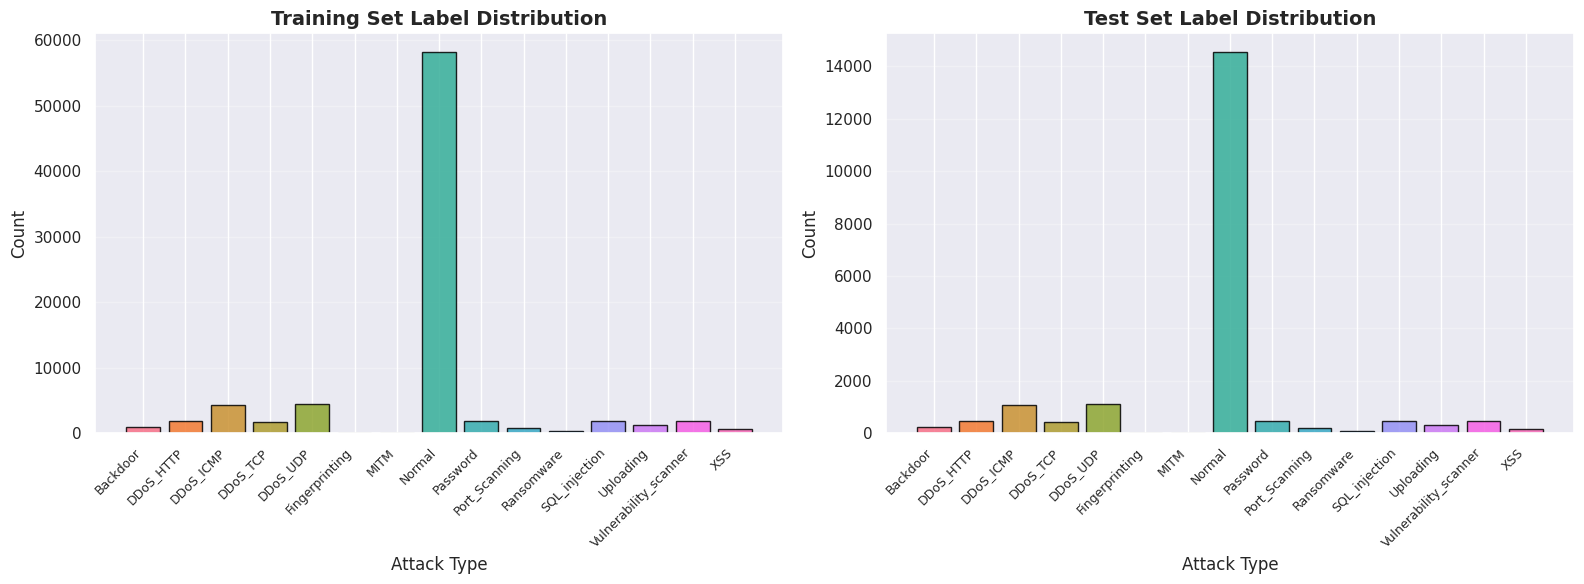

In [7]:
#@title Visualize Class Distributions { display-mode: "form" }

# Visualize class distributions with class labels and distinct colors per class
if df is not None and not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Build a color map: one distinct color per class
    n_classes = len(label_mapping)
    class_palette = sns.color_palette("husl", n_classes)
    class_colors = {cls_idx: class_palette[cls_idx] for cls_idx in range(n_classes)}

    # Training set
    unique_train, counts_train = np.unique(y_train_glob, return_counts=True)
    train_colors = [class_colors[c] for c in unique_train]
    axes[0].bar(unique_train, counts_train, color=train_colors, alpha=0.85, edgecolor='black')
    axes[0].set_xlabel('Attack Type', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Training Set Label Distribution', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    # Class labels on x-axis
    axes[0].set_xticks(unique_train)
    axes[0].set_xticklabels([reverse_label_mapping[c] for c in unique_train],
                             rotation=45, ha='right', fontsize=9)

    # Test set
    unique_test, counts_test = np.unique(y_test_glob, return_counts=True)
    test_colors = [class_colors[c] for c in unique_test]
    axes[1].bar(unique_test, counts_test, color=test_colors, alpha=0.85, edgecolor='black')
    axes[1].set_xlabel('Attack Type', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title('Test Set Label Distribution', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    # Class labels on x-axis
    axes[1].set_xticks(unique_test)
    axes[1].set_xticklabels([reverse_label_mapping[c] for c in unique_test],
                             rotation=45, ha='right', fontsize=9)

    plt.tight_layout()
    plt.show()

# Create the federated dataset

This core function allows the creation of FL data from centralized data. The class `SplitAsFederatedData` is instantiated using a `random_state` to reproduce the results.

Then, the `.create_clients` function performs the federation of the centralized data by taking the features and labels, defining the number of desired clients and setting the Alpha value.

**Note:** When creating federated data and setting heterogeneous distributions (i.e. high values of percent_noniid or small values of Alpha), it is more likely the clients hold examples from only one class. Then, two cases are returned as output for fed_data and distances:
- "with_class_completion": In this case, the clients are completed with one (random) example of each missing class for each client to have all the label's classes.
- "without_class_completion": In this case, the clients are NOT completed with one (random) example of each missing class.

In [8]:
#@title FEDERATED LEARNING CONFIGURATION: Set Parameters Here { display-mode: "form" }

# ================================================================================
# USER INPUT - SET THESE PARAMETERS ONLY ONCE
# These will be used throughout the entire notebook for federated dataset creation
# ================================================================================

# Number of clients/local nodes for federated learning
num_clients = 6  # @param {type: "integer", min: 2, max: 50, step: 1}

# Distribution method for data heterogeneity
distribution_method = "dirichlet"  # @param ["dirichlet", "percent_noniid", "no-label-skew"]

# Heterogeneity parameter (alpha)
# - For Dirichlet: controls concentration (smaller = more non-IID)
# - For Percent Non-IID: converted to percentage (0-100)
# - For IID: ignored (uniform distribution)
alpha = 0.001  # @param {type: "number", min: 0.001, max: 10.0, step: 0.1}

# Class completion strategy
# - "with_class_completion": Each client gets at least one sample from all classes
# - "without_class_completion": Clients may have missing classes (true non-IID scenario)
class_completion = "without_class_completion"  # @param ["with_class_completion", "without_class_completion"]

# ================================================================================
# DISPLAY CONFIGURATION SUMMARY
# ================================================================================

print("\n" + "="*80)
print("FEDERATED LEARNING CONFIGURATION - Ready to Create Dataset")
print("="*80)
print(f"\n  ✓ Number of Clients: {num_clients}")
print(f"  ✓ Distribution Method: {distribution_method.upper()}")
print(f"  ✓ Heterogeneity Parameter (alpha): {alpha}")
print(f"  ✓ Class Completion: {class_completion.upper()}")

print("\n" + "-"*80)
print("SELECTED METHOD DETAILS:")
print("-"*80)

if distribution_method == "dirichlet":
    print(f"\n  METHOD: Dirichlet Distribution (LABEL SKEW)")
    print(f"  Alpha = {alpha}")
    print(f"\n  What it does:")
    print(f"    • Each client receives a different subset of labels")
    print(f"    • Smaller alpha → More non-IID (heterogeneous)")
    print(f"    • Larger alpha → More balanced (approaching IID)")

elif distribution_method == "percent_noniid":
    percent_val = max(0, min(100, (alpha / 10.0) * 100))
    print(f"\n  METHOD: Percent Non-IID Distribution")
    print(f"  Alpha = {alpha} (converted to {percent_val:.1f}% non-IID)")
    print(f"\n  What it does:")
    print(f"    • Each client has different class distributions")
    print(f"    • Based on percentage of non-IID samples")

elif distribution_method == "no-label-skew":
    print(f"\n  METHOD: No Label Skew (IID Distribution)")
    print(f"  Alpha parameter: IGNORED")
    print(f"\n  What it does:")
    print(f"    • Each client gets balanced class distribution")
    print(f"    • All clients have similar label proportions")

print("\n" + "-"*80)
print("CLASS COMPLETION STRATEGY:")
print("-"*80)

if class_completion == "with_class_completion":
    print(f"\n  ✓ WITH Class Completion")
    print(f"  Each client will receive at least 1 sample from every class")
    print(f"  • Ensures all classes are represented in each client")
    print(f"  • Reduces data heterogeneity")
    print(f"  • Useful for testing federated learning algorithms")
else:
    print(f"\n  ✓ WITHOUT Class Completion")
    print(f"  Clients may have missing classes (true non-IID scenario)")
    print(f"  • Reflects real-world federated scenarios")
    print(f"  • Higher data heterogeneity")
    print(f"  • More challenging for federated learning")

print("\n" + "="*80)
print(f"✓ Ready to create {num_clients} clients with:")
print(f"  - Distribution: {distribution_method}")
print(f"  - Class Completion: {class_completion}")
print("="*80 + "\n")


FEDERATED LEARNING CONFIGURATION - Ready to Create Dataset

  ✓ Number of Clients: 6
  ✓ Distribution Method: DIRICHLET
  ✓ Heterogeneity Parameter (alpha): 0.001
  ✓ Class Completion: WITHOUT_CLASS_COMPLETION

--------------------------------------------------------------------------------
SELECTED METHOD DETAILS:
--------------------------------------------------------------------------------

  METHOD: Dirichlet Distribution (LABEL SKEW)
  Alpha = 0.001

  What it does:
    • Each client receives a different subset of labels
    • Smaller alpha → More non-IID (heterogeneous)
    • Larger alpha → More balanced (approaching IID)

--------------------------------------------------------------------------------
CLASS COMPLETION STRATEGY:
--------------------------------------------------------------------------------

  ✓ WITHOUT Class Completion
  Clients may have missing classes (true non-IID scenario)
  • Reflects real-world federated scenarios
  • Higher data heterogeneity
  • More

In [9]:
#@title Instantiate a SplitAsFederatedData object { display-mode: "form" }
if df is not None and not df.empty:
    # Instantiate a SplitAsFederatedData object
    my_federater = SplitAsFederatedData(random_state = random_state)

    print("\n" + "="*80)
    print("CREATING FEDERATED DATASET")
    print("="*80)
    print(f"Method: {distribution_method}")
    print(f"Number of clients: {num_clients}")
    print(f"Class Completion: {class_completion}")

    # Create clients based on selected distribution method
    if distribution_method == "dirichlet":
        print(f"Alpha: {alpha}")
        clients_glob_dic, list_ids_sampled_dic, miss_class_per_node, distances = my_federater.create_clients(
            image_list = x_train_glob,
            label_list = y_train_glob,
            num_clients = num_clients,
            prefix_cli='Local_node',
            method = "dirichlet",
            alpha = alpha
        )
        print(f"\n✓ Dirichlet distribution created successfully")

    elif distribution_method == "percent_noniid":
        percent_value = max(0, min(100, (alpha / 10.0) * 100))
        print(f"Alpha: {alpha} → {percent_value:.1f}% non-IID")
        clients_glob_dic, list_ids_sampled_dic, miss_class_per_node, distances = my_federater.create_clients(
            image_list = x_train_glob,
            label_list = y_train_glob,
            num_clients = num_clients,
            prefix_cli='Local_node',
            method = "percent_noniid",
            alpha = percent_value
        )
        print(f"\n✓ Percent Non-IID distribution created successfully")

    elif distribution_method == "no-label-skew":
        print(f"Alpha: IGNORED (IID distribution)")
        clients_glob_dic, list_ids_sampled_dic, miss_class_per_node, distances = my_federater.create_clients(
            image_list = x_train_glob,
            label_list = y_train_glob,
            num_clients = num_clients,
            prefix_cli='Local_node',
            method = "no-label-skew",
            alpha = None
        )
        print(f"\n✓ IID (no label skew) distribution created successfully")

    clients_glob = clients_glob_dic[class_completion]
    list_ids_sampled = list_ids_sampled_dic[class_completion]

    # Convert from SplitAsFederatedData function output (FedArtML) to Flower (list) format
    list_x_train, list_y_train = from_FedArtML_to_Flower_format(clients_dict=clients_glob)

    print(f"\nFederated dataset statistics:")
    print(f"  - Number of clients created: {len(list_x_train)}")
    print(f"  - Training samples per client: {[len(x) for x in list_x_train]}")
    print("="*80 + "\n")


CREATING FEDERATED DATASET
Method: dirichlet
Number of clients: 6
Class Completion: without_class_completion
Alpha: 0.001


/home/pctablet505/snap/code/247/.local/share/uv/python/cpython-3.13.13-linux-x86_64-gnu/lib/python3.13/site-packages/fedartml/fl_split_as_federated_data.py:185: RuntimeWarning: invalid value encountered in cast
  proportions = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]



✓ Dirichlet distribution created successfully

Federated dataset statistics:
  - Number of clients created: 6
  - Training samples per client: [7661, 598, 3957, 952, 6528, 60304]



In [10]:
#@title Create Balanced Federated Dataset { display-mode: "form" }

if df is not None and not df.empty:
    print('\n' + '='*80)
    print('CREATING BALANCED FEDERATED DATASET (with class completion)')
    print('='*80)
    clients_glob_bal, list_ids_sampled_bal, miss_class_per_node_bal, distances_bal = my_federater.create_clients(
        image_list=x_train_glob,
        label_list=y_train_glob,
        num_clients=num_clients,
        prefix_cli='Local_node',
        method='dirichlet',
        alpha=alpha
    )
    clients_glob_bal = clients_glob_bal['with_class_completion']
    list_x_train_bal, list_y_train_bal = from_FedArtML_to_Flower_format(clients_dict=clients_glob_bal)
    print(f'✓ Balanced clients created: samples per client = {[len(x) for x in list_x_train_bal]}')
    print('='*80 + '\n')


CREATING BALANCED FEDERATED DATASET (with class completion)


/home/pctablet505/snap/code/247/.local/share/uv/python/cpython-3.13.13-linux-x86_64-gnu/lib/python3.13/site-packages/fedartml/fl_split_as_federated_data.py:185: RuntimeWarning: invalid value encountered in cast
  proportions = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]


✓ Balanced clients created: samples per client = [7672, 611, 3969, 965, 6539, 60316]



In [11]:
#@title Calculate Distances { display-mode: "form" }

if df is not None and not df.empty:
    # Calculate distances
    JSD_glob = distances[class_completion]['jensen-shannon']
    print("Jensen-Shannon distance:", JSD_glob)
    HD_glob = distances[class_completion]['hellinger']
    print("Hellinger distance:", HD_glob)

    EMD_glob = distances[class_completion]['earth-movers']
    print("Earth Mover's distance:", EMD_glob)

Jensen-Shannon distance: 0.9745947444594844
Hellinger distance: 0.9858478705929133
Earth Mover's distance: 0.20347735025037006



CLIENT DISTRIBUTION VISUALIZATION - STANDARD COLOR PALETTE (3x2)


/tmp/ipykernel_744796/3530063186.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.98])


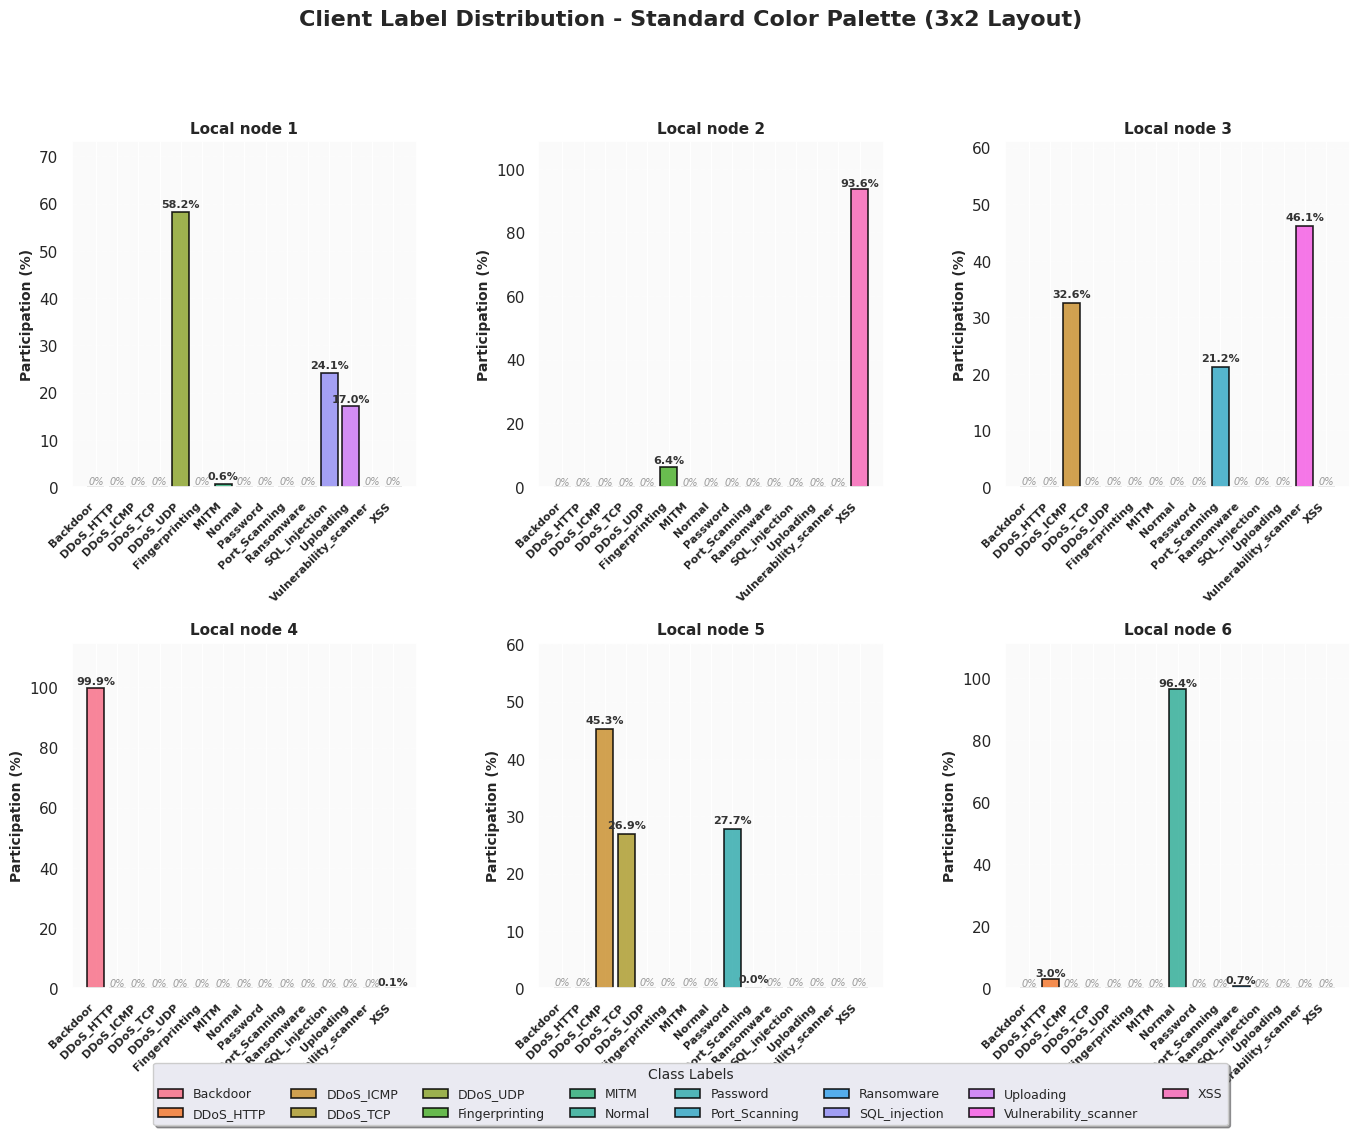


[STANDARD PALETTE] Using 'husl' colormap from seaborn
----------------------------------------------------------------------------------------------------
✓ Number of classes: 15
✓ Layout: 3 columns x 2 rows
✓ Palette: HLS (Hue, Lightness, Saturation)

Color assignments:
  • Backdoor        → #f67088
  • DDoS_HTTP       → #f37932
  • DDoS_ICMP       → #ca9131
  • DDoS_TCP        → #ad9c31
  • DDoS_UDP        → #8ea531
  • Fingerprinting  → #4fb031
  • MITM            → #33b07a
  • Normal          → #34ad99
  • Password        → #36abae
  • Port_Scanning   → #38a8c5
  • Ransomware      → #3ba3ec
  • SQL_injection   → #9491f4
  • Uploading       → #cc79f4
  • Vulnerability_scanner → #f45fe3
  • XSS             → #f569b7

✓ Visualization complete



In [12]:
#@title Visualize Client Distributions { display-mode: "form" }
if df is not None and not df.empty:
    # ================================================================================
    # STANDARD COLOR PALETTE VISUALIZATION - 3x2 Layout
    # ================================================================================

    standard_palette = sns.color_palette("husl", len(label_mapping))

    label_to_standard_color = {
        label: standard_palette[idx] for idx, label in enumerate(sorted(label_mapping.keys()))
    }

    print("\n" + "="*100)
    print("CLIENT DISTRIBUTION VISUALIZATION - STANDARD COLOR PALETTE (3x2)")
    print("="*100)

    reverse_label_mapping = {v: k for k, v in label_mapping.items()}
    standard_plot_data = {}

    for key, value in clients_glob.items():
        labels_check = []
        for i in range(len(value)):
            val = value[i][1]
            labels_check.append(val)

        labels_check = pd.DataFrame(labels_check, columns=["label"]).reset_index()
        group = labels_check.groupby(['label']).count().reset_index().sort_values(by=['label'], ascending=True)
        group['particip'] = (group['index'].values / sum(group['index'].values)) * 100
        group.sort_values(by=['particip'], ascending=True, inplace=True)
        group['label_name'] = group['label'].map(reverse_label_mapping)

        group['color'] = group['label_name'].map(label_to_standard_color)
        standard_plot_data[key] = group

    all_labels_sorted = sorted(label_mapping.keys())

    # Fixed 3 columns x 2 rows layout
    cols = 3
    rows = 2
    fig = plt.figure(figsize=(cols * 5.5, rows * 5.5))
    gs = fig.add_gridspec(rows, cols, hspace=0.45, wspace=0.35)

    cont = 0
    for key, group in standard_plot_data.items():
        row = cont // cols
        col = cont % cols
        ax = fig.add_subplot(gs[row, col])

        all_labels_df = pd.DataFrame({'label_name': all_labels_sorted})
        group_full = all_labels_df.merge(
            group[['label_name', 'particip', 'color']],
            on='label_name',
            how='left'
        )
        group_full['particip'] = group_full['particip'].fillna(0)
        group_full['color'] = group_full['label_name'].map(label_to_standard_color)

        x_pos = np.arange(len(group_full))
        bars = ax.bar(x_pos, group_full['particip'].values, color=group_full['color'].values,
                      edgecolor='black', linewidth=1.2, alpha=0.85)

        for i, (x, value) in enumerate(zip(x_pos, group_full['particip'].values)):
            if value > 0:
                ax.text(x, value + 1, f'{value:.1f}%', ha='center', fontsize=8,
                       fontweight='bold', color='#333333')
            else:
                ax.text(x, 0.5, '0%', ha='center', fontsize=7,
                       color='#999999', style='italic')

        ax.set_xticks(x_pos)
        ax.set_xticklabels(group_full['label_name'].values, fontsize=8, fontweight='bold',
                            rotation=45, ha='right')
        ax.set_ylabel('Participation (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{key.replace("_", " ")}', fontsize=11, fontweight='bold')
        ax.set_ylim(bottom=0, top=max(group_full['particip']) + 15 if max(group_full['particip']) > 0 else 20)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        ax.set_facecolor('#fafafa')

        cont += 1

    # Hide unused subplot (position 5 is the 6th slot, unused with 5 clients)
    if cont < cols * rows:
        ax_empty = fig.add_subplot(gs[rows-1, cols-1])
        ax_empty.axis('off')

    # Global legend below the grid
    legend_patches = []
    for label in all_labels_sorted:
        color = label_to_standard_color[label]
        legend_patches.append(plt.Rectangle((0, 0), 1, 1, facecolor=color,
                              edgecolor='black', linewidth=1.2, alpha=0.85))

    fig.legend(legend_patches, all_labels_sorted, loc='lower center',
               ncol=min(8, len(all_labels_sorted)), fontsize=9,
               title='Class Labels', title_fontsize=10,
               frameon=True, fancybox=True, shadow=True,
               bbox_to_anchor=(0.5, -0.02))

    fig.suptitle('Client Label Distribution - Standard Color Palette (3x2 Layout)',
                fontsize=16, fontweight='bold', y=1.00)

    plt.tight_layout(rect=[0, 0.06, 1, 0.98])
    plt.show()

    print("\n[STANDARD PALETTE] Using 'husl' colormap from seaborn")
    print("-" * 100)
    print(f"✓ Number of classes: {len(label_mapping)}")
    print(f"✓ Layout: 3 columns x 2 rows")
    print(f"✓ Palette: HLS (Hue, Lightness, Saturation)")
    print(f"\nColor assignments:")
    for label in sorted(label_mapping.keys()):
        color_rgb = label_to_standard_color[label]
        color_hex = '#{:02x}{:02x}{:02x}'.format(
            int(color_rgb[0]*255), int(color_rgb[1]*255), int(color_rgb[2]*255)
        )
        print(f"  • {label:<15} → {color_hex}")

    print("\n" + "="*100)
    print("✓ Visualization complete")
    print("="*100 + "\n")


CLIENT DISTRIBUTION DATA - PROFESSIONAL TABLE FOR REPORT



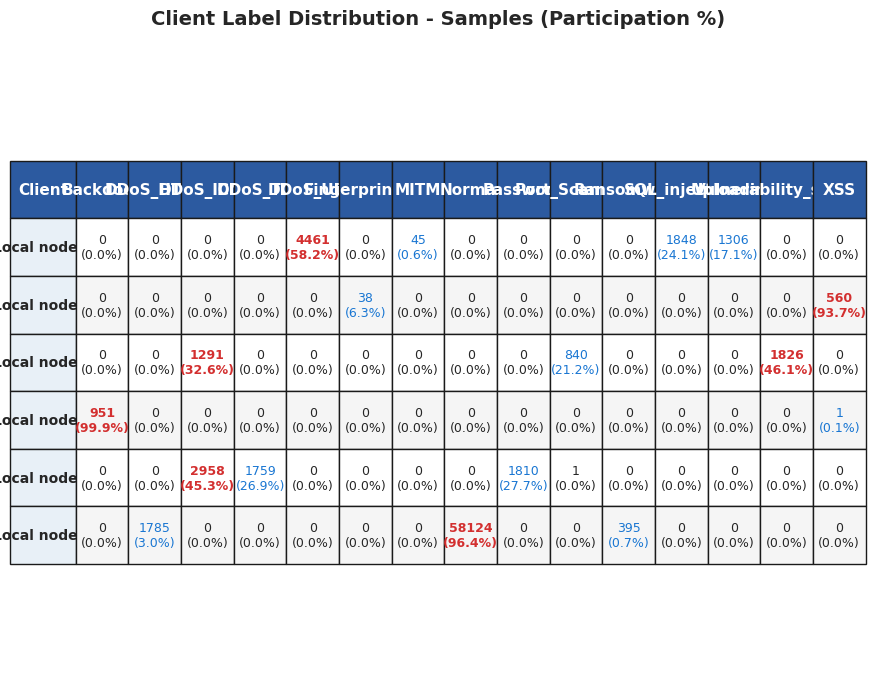

✓ Professional table saved as 'client_distribution_table.png'

----------------------------------------------------------------------------------------------------
SUMMARY STATISTICS BY CLASS
----------------------------------------------------------------------------------------------------



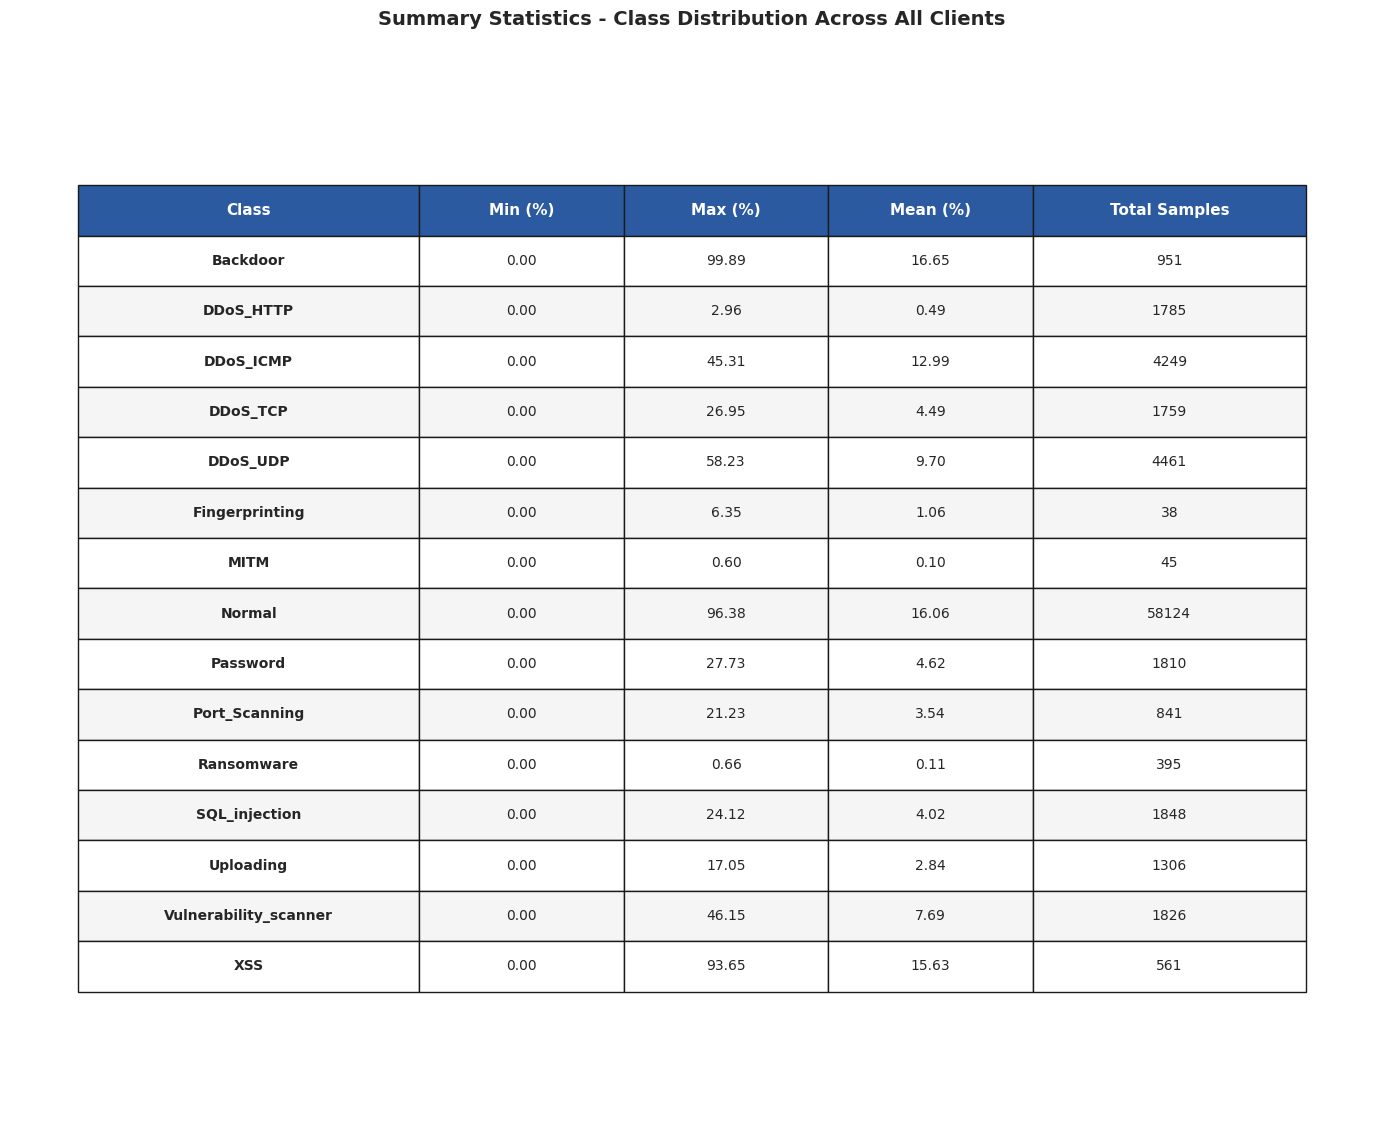


✓ Summary statistics table saved as 'class_summary_statistics_table.png'

----------------------------------------------------------------------------------------------------
DATA EXPORT
----------------------------------------------------------------------------------------------------
✓ Full report data available in 'report_df' variable
✓ Pivot table (percentages) available in 'pivot_table' variable
✓ Pivot table (samples) available in 'pivot_samples' variable
✓ Export full data: report_df.to_csv('client_distribution_report.csv', index=False)
✓ Export summary: summary_stats.to_csv('class_summary_statistics.csv')

✓ Professional tables created with sample counts and percentages



In [13]:
#@title Export Client Data as Tables for Report { display-mode: "form" }

if df is not None and not df.empty:
    print("\n" + "="*100)
    print("CLIENT DISTRIBUTION DATA - PROFESSIONAL TABLE FOR REPORT")
    print("="*100 + "\n")

    report_data = []

    for client_idx, (key, group) in enumerate(standard_plot_data.items(), 1):
        all_labels_df = pd.DataFrame({'label_name': all_labels_sorted})
        group_full = all_labels_df.merge(
            group[['label_name', 'particip']],
            on='label_name',
            how='left'
        )
        group_full['particip'] = group_full['particip'].fillna(0)

        client_data = clients_glob[key]
        total_samples = len(client_data)

        for label_name, participation in zip(group_full['label_name'], group_full['particip']):
            num_samples = int((participation / 100) * total_samples) if participation > 0 else 0
            report_data.append({
                'Client': key.replace('_', ' '),
                'Class': label_name,
                'Participation (%)': f"{participation:.2f}",
                'Samples': num_samples
            })

    report_df = pd.DataFrame(report_data)

    pivot_table = report_df.pivot_table(
        index='Client',
        columns='Class',
        values='Participation (%)',
        aggfunc='first'
    ).fillna('0.00')

    pivot_samples = report_df.pivot_table(
        index='Client',
        columns='Class',
        values='Samples',
        aggfunc='first'
    ).fillna(0).astype(int)

    fig, ax = plt.subplots(figsize=(18, 7))
    ax.axis('tight')
    ax.axis('off')

    table_data = []
    table_data.append(['Client'] + list(pivot_table.columns))

    for client_idx, row in pivot_table.iterrows():
        row_data = [client_idx]
        for col_idx, col in enumerate(pivot_table.columns):
            percentage = float(row[col])
            samples = int(pivot_samples.loc[client_idx, col])
            cell_value = f"{samples}\n({percentage:.1f}%)"
            row_data.append(cell_value)
        table_data.append(row_data)

    table = ax.table(
        cellText=table_data,
        cellLoc='center',
        loc='center',
        colWidths=[0.15] + [0.12] * len(pivot_table.columns)
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 3)

    for i in range(len(pivot_table.columns) + 1):
        cell = table[(0, i)]
        cell.set_facecolor('#2C5AA0')
        cell.set_text_props(weight='bold', color='white', fontsize=11)

    for i in range(1, len(pivot_table) + 1):
        cell = table[(i, 0)]
        cell.set_facecolor('#E8F0F7')
        cell.set_text_props(weight='bold', fontsize=10)

    for i in range(1, len(pivot_table) + 1):
        for j in range(1, len(pivot_table.columns) + 1):
            cell = table[(i, j)]
            if i % 2 == 0:
                cell.set_facecolor('#F5F5F5')
            else:
                cell.set_facecolor('#FFFFFF')

            try:
                cell_text = table_data[i][j]
                percentage_str = cell_text.split('(')[1].replace('%)', '')
                val = float(percentage_str)
                if val > 30:
                    cell.set_text_props(weight='bold', color='#D32F2F')
                elif val > 0:
                    cell.set_text_props(color='#1976D2')
            except:
                pass

    plt.title('Client Label Distribution - Samples (Participation %)',
              fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig('client_distribution_table.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print("✓ Professional table saved as 'client_distribution_table.png'")

    print("\n" + "-" * 100)
    print("SUMMARY STATISTICS BY CLASS")
    print("-" * 100 + "\n")

    summary_by_class = report_df.copy()
    summary_by_class['Participation (%)'] = summary_by_class['Participation (%)'].astype(float)
    summary_stats = summary_by_class.groupby('Class').agg({
        'Participation (%)': ['min', 'max', 'mean'],
        'Samples': 'sum'
    }).round(2)
    summary_stats.columns = ['Min (%)', 'Max (%)', 'Mean (%)', 'Total Samples']

    fig, ax = plt.subplots(figsize=(14, len(summary_stats) * 0.7 + 1))
    ax.axis('tight')
    ax.axis('off')

    summary_table_data = [['Class', 'Min (%)', 'Max (%)', 'Mean (%)', 'Total Samples']]
    for class_name, row in summary_stats.iterrows():
        summary_table_data.append([
            class_name,
            f"{row['Min (%)']:.2f}",
            f"{row['Max (%)']:.2f}",
            f"{row['Mean (%)']:.2f}",
            f"{int(row['Total Samples'])}"
        ])

    summary_table = ax.table(
        cellText=summary_table_data,
        cellLoc='center',
        loc='center',
        colWidths=[0.25, 0.15, 0.15, 0.15, 0.20]
    )

    summary_table.auto_set_font_size(False)
    summary_table.set_fontsize(10)
    summary_table.scale(1, 2.5)

    for i in range(5):
        cell = summary_table[(0, i)]
        cell.set_facecolor('#2C5AA0')
        cell.set_text_props(weight='bold', color='white', fontsize=11)

    for i in range(1, len(summary_stats) + 1):
        for j in range(5):
            cell = summary_table[(i, j)]
            if i % 2 == 0:
                cell.set_facecolor('#F5F5F5')
            else:
                cell.set_facecolor('#FFFFFF')

            if j == 0:
                cell.set_text_props(weight='bold')

    plt.title('Summary Statistics - Class Distribution Across All Clients',
              fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig('class_summary_statistics_table.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print("\n✓ Summary statistics table saved as 'class_summary_statistics_table.png'")

    print("\n" + "-" * 100)
    print("DATA EXPORT")
    print("-" * 100)
    print(f"✓ Full report data available in 'report_df' variable")
    print(f"✓ Pivot table (percentages) available in 'pivot_table' variable")
    print(f"✓ Pivot table (samples) available in 'pivot_samples' variable")
    print(f"✓ Export full data: report_df.to_csv('client_distribution_report.csv', index=False)")
    print(f"✓ Export summary: summary_stats.to_csv('class_summary_statistics.csv')")

    print("\n" + "="*100)
    print("✓ Professional tables created with sample counts and percentages")
    print("="*100 + "\n")

# Train and Compare All Models

Up to this point, we have shown how to use the **FedArtML** to create a federated dataset starting from centralized data. Then, we introduce the code to train an FL model using the **Flower framework** with the **DeepFed** CNN-GRU architecture (Li et al., IEEE TII 2021).

In [14]:
#@title Configure Training Parameters { display-mode: "form" }

if df is not None and not df.empty:
    loss_inic = losses_mod.SparseCategoricalCrossentropy()
    metric_obj = metrics_mod.SparseCategoricalAccuracy()
    epochs = 3
    comms_round = 5

    print("Training Configuration:")
    print(f"  - Local epochs per round: {epochs}")
    print(f"  - Communication rounds: {comms_round}")
    print(f"  - Number of clients: {num_clients}")
    print(f"  - Input shape: {input_shape}")
    print(f"  - Output classes: {num_classes}")

Training Configuration:
  - Local epochs per round: 3
  - Communication rounds: 5
  - Number of clients: 6
  - Input shape: (35, 1)
  - Output classes: 15


In [15]:
#@title Experiment 1: Unbalanced Data, No Rebalancing { display-mode: "form" }

if df is not None and not df.empty:
    def run_fl_simulation(model_builder, model_name,
                          client_class=FlowerClient, client_kwargs=None,
                          x_clients=None, y_clients=None, aug_cache=None):
        print("\n" + "="*70)
        print(f"  MODEL: {model_name} | client={client_class.__name__}")
        print("="*70)

        def evaluate_fn(server_round, parameters, config):
            net = model_builder(input_shape, num_classes)
            net.set_weights(parameters)
            loss, acc, bacc, pre, rec, f1s, f1_macro = test_model(net, x_test_glob, y_test_glob)
            print(f"  [R{server_round}] acc={acc:.4f}  f1={f1s:.4f}  f1_macro={f1_macro:.4f}")
            return loss, {"accuracy": acc, "balanced_accuracy": bacc,
                          "precision": pre, "recall": rec,
                          "f1score": f1s, "f1_macro": f1_macro}

        def client_fn(cid):
            model = model_builder(input_shape, num_classes)
            kwargs = dict(client_kwargs) if client_kwargs else {}
            if aug_cache is not None:
                # FedIDS: reuse the driver-precomputed balanced+augmented shard for
                # this client (identical deterministic result) instead of rerunning
                # augmentation on every fit/evaluate task.
                kwargs["precomputed"] = aug_cache[int(cid)]
                x_train_cid = y_train_cid = None
            else:
                x_list = x_clients if x_clients is not None else list_x_train
                y_list = y_clients if y_clients is not None else list_y_train
                x_train_cid = np.array(x_list[int(cid)], dtype=np.float32)
                y_train_cid = np.array(y_list[int(cid)], dtype=int)
                if "seed" in kwargs:
                    kwargs["seed"] = kwargs["seed"] + int(cid) * 1000
            client = client_class(model, x_train_cid, y_train_cid,
                                  x_test_glob, y_test_glob, epochs,
                                  **kwargs)
            return client.to_client()

        # Centralized evaluate_fn (above) already scores the full test set every
        # round and is the ONLY consumed metric source (results read
        # hist.metrics_centralized), so per-client federated evaluation is pure
        # overhead - disabled here (for FedIDS it would also rebuild a client,
        # i.e. full augmentation, just to evaluate).
        # initial_parameters seeds the global model so Flower doesn't spawn a
        # throwaway client just to fetch starting weights.
        initial_parameters = fl.common.ndarrays_to_parameters(
            model_builder(input_shape, num_classes).get_weights())

        strategy = fl.server.strategy.FedAvg(
            fraction_fit=1.0,
            fraction_evaluate=0.0,
            min_fit_clients=num_clients,
            min_evaluate_clients=0,
            min_available_clients=num_clients,
            evaluate_fn=evaluate_fn,
            initial_parameters=initial_parameters,
        )

        # Only request a GPU actor slot if one was actually detected (reusing the
        # `has_gpu` flag from the JAX device-detection cell above) — otherwise Ray
        # will wait forever for a GPU that doesn't exist and the simulation hangs.
        # Fractional GPU: let ~2 client actors share the GPU (0.5 each) instead of
        # fully serializing on it. 0.5 is sized conservatively for a 6 GB RTX 4050
        # laptop card (2 concurrent JAX/XLA contexts fit within MEM_FRACTION=0.30).
        client_resources = {"num_cpus": 2, "num_gpus": 0.5} if has_gpu else {"num_cpus": 1}
        ray_init_args = {"num_gpus": 1} if has_gpu else {"num_cpus": num_clients}

        hist = fl.simulation.start_simulation(
            client_fn=client_fn,
            num_clients=num_clients,
            config=fl.server.ServerConfig(num_rounds=comms_round),
            strategy=strategy,
            client_resources=client_resources,
            ray_init_args=ray_init_args,
        )

        # Extract metrics before discarding heavy history object
        rounds_acc, vals_acc = zip(*hist.metrics_centralized["accuracy"])
        rounds_bacc, vals_bacc = zip(*hist.metrics_centralized["balanced_accuracy"])
        rounds_pre, vals_pre = zip(*hist.metrics_centralized["precision"])
        rounds_rec, vals_rec = zip(*hist.metrics_centralized["recall"])
        rounds_f1,  vals_f1  = zip(*hist.metrics_centralized["f1score"])
        rounds_f1m, vals_f1m = zip(*hist.metrics_centralized["f1_macro"])

        result = {
            "accuracy": retrieve_global_metrics(hist, "centralized", "accuracy", False),
            "balanced_accuracy": retrieve_global_metrics(hist, "centralized", "balanced_accuracy", False),
            "precision": retrieve_global_metrics(hist, "centralized", "precision", False),
            "recall": retrieve_global_metrics(hist, "centralized", "recall", False),
            "f1score": retrieve_global_metrics(hist, "centralized", "f1score", False),
            "f1_macro": retrieve_global_metrics(hist, "centralized", "f1_macro", False),
            "rounds": rounds_acc,
            "acc_history": vals_acc,
            "bacc_history": vals_bacc,
            "pre_history": vals_pre,
            "rec_history": vals_rec,
            "f1_history": vals_f1,
            "f1_macro_history": vals_f1m,
        }

        # Free memory: delete history, clear Keras session, clear JAX caches, GC
        del hist
        keras.backend.clear_session()
        try:
            import jax
            jax.clear_caches()
        except Exception:
            pass
        gc.collect()

        return result

    model_builders = {
        "DNN": dnn_model,
        "CNN+GRU (DeepFed)": DeepFed_model,
        "CNN+LSTM": cnn_lstm_model,
        "Transformer": transformer_model,
    }

    results_unbalanced = {}
    for name, builder in model_builders.items():
        results_unbalanced[name] = run_fl_simulation(builder, name)
        print(f"  ✓ {name} complete — memory freed")

    print("\n" + "="*70)
    print("  ALL MODELS COMPLETE")
    print("="*70)
    for name, res in results_unbalanced.items():
        print(f"  {name:20s} | Acc: {res['accuracy']:.4f} | F1: {res['f1score']:.4f} | MacroF1: {res['f1_macro']:.4f}")


  MODEL: DNN | client=FlowerClient


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        


INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout


/home/pctablet505/snap/code/247/.local/share/uv/python/cpython-3.13.13-linux-x86_64-gnu/lib/python3.13/subprocess.py:1921: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


/home/pctablet505/snap/code/247/.local/share/uv/python/cpython-3.13.13-linux-x86_64-gnu/lib/python3.13/subprocess.py:1921: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


...

INFO :      	            (4, 0.7315),


INFO :      	            (5, 0.73345)]}


INFO :      


  [R5] acc=0.7335  f1=0.8296  f1_macro=0.0802


  ✓ Transformer complete — memory freed

  ALL MODELS COMPLETE
  DNN                  | Acc: 0.7346 | F1: 0.8300 | MacroF1: 0.0823
  CNN+GRU (DeepFed)    | Acc: 0.7345 | F1: 0.8269 | MacroF1: 0.0802
  CNN+LSTM             | Acc: 0.7342 | F1: 0.8284 | MacroF1: 0.0802
  Transformer          | Acc: 0.7335 | F1: 0.8296 | MacroF1: 0.0802


# Experiment 2: Balanced Data, No Rebalancing

This experiment uses an **IID-like balanced federated split** (class-completion) with plain FedAvg, so we can compare it against the highly heterogeneous unbalanced baseline.

In [16]:
#@title Experiment 2: Balanced Data, No Rebalancing { display-mode: "form" }

if df is not None and not df.empty:
    print('\n' + '='*80)
    print('EXPERIMENT 2: BALANCED DATA — No Rebalancing')
    print('='*80)
    results_balanced = {}
    for name, builder in model_builders.items():
        results_balanced[name] = run_fl_simulation(builder, name,
                                                    x_clients=list_x_train_bal,
                                                    y_clients=list_y_train_bal)
        print(f"  ✓ {name} complete — memory freed")

    print("\n" + "="*70)
    print("  ALL MODELS COMPLETE")
    print("="*70)
    for name, res in results_balanced.items():
        print(f"  {name:20s} | Acc: {res['accuracy']:.4f} | F1: {res['f1score']:.4f} | MacroF1: {res['f1_macro']:.4f}")

/home/pctablet505/Projects/keras/keras/src/backend/common/variables.py:252: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(self)
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        


INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout



EXPERIMENT 2: BALANCED DATA — No Rebalancing

  MODEL: DNN | client=FlowerClient


/home/pctablet505/snap/code/247/.local/share/uv/python/cpython-3.13.13-linux-x86_64-gnu/lib/python3.13/subprocess.py:1921: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


2026-07-03 10:43:59,742	INFO worker.py:2012 -- Started a local Ray instance.


...

INFO :      	            (4, 0.73365),


INFO :      	            (5, 0.73055)]}


INFO :      


  [R5] acc=0.7306  f1=0.8328  f1_macro=0.0838


  ✓ Transformer complete — memory freed

  ALL MODELS COMPLETE
  DNN                  | Acc: 0.7426 | F1: 0.8294 | MacroF1: 0.0994
  CNN+GRU (DeepFed)    | Acc: 0.7432 | F1: 0.8316 | MacroF1: 0.1131
  CNN+LSTM             | Acc: 0.7378 | F1: 0.8284 | MacroF1: 0.1023
  Transformer          | Acc: 0.7306 | F1: 0.8328 | MacroF1: 0.0838


# Experiment 3: Unbalanced Data + Full Fed-IDS Improvements

This experiment keeps the **same unbalanced Dirichlet split** used in the baseline, but replaces the plain `FlowerClient` with the full Fed-IDS client: balanced local sampling, covariance-based feature-space augmentation, knowledge distillation from the server model, and smooth regularisation.

In [17]:
#@title Experiment 3: Unbalanced Data + Full Fed-IDS Improvements { display-mode: "form" }

if df is not None and not df.empty:
    print('\n' + '='*80)
    print('EXPERIMENT 2: UNBALANCED DATA — Full Fed-IDS (balanced sampling + feature aug + KD + smooth reg)')
    print('='*80)
    # Precompute each client's balanced+augmented shard ONCE (deterministic per
    # cid) so Flower reuses it across every fit task instead of recomputing the
    # identical augmentation dozens of times. Each entry is
    # (x_aug, y_aug, n_true, c_neg_mask).
    TEMPERATURE = 2.0
    LAMBDA1 = 1.0
    aug_cache = {
        cid: prepare_fedids_client_data(
            np.array(list_x_train[cid], dtype=np.float32),
            np.array(list_y_train[cid], dtype=int),
            num_classes,
            seed=random_state + cid * 1000)
        for cid in range(num_clients)
    }

    results_fedids = {}
    for name, builder in model_builders.items():
        # temperature must match between the client's teacher softening and the
        # loss's student softening -> thread the same TEMPERATURE to both.
        fedids_builder = lambda shape, classes, b=builder: make_fedids_model(
            b, shape, classes, lambda1=LAMBDA1, temperature=TEMPERATURE)
        results_fedids[name] = run_fl_simulation(
            fedids_builder, name,
            client_class=FedIDSClient,
            client_kwargs={"num_classes": num_classes, "temperature": TEMPERATURE},
            aug_cache=aug_cache)
        print(f'  ✓ {name} complete')


EXPERIMENT 2: UNBALANCED DATA — Full Fed-IDS (balanced sampling + feature aug + KD + smooth reg)

  MODEL: DNN | client=FedIDSClient


/home/pctablet505/Projects/keras/keras/src/backend/common/variables.py:252: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(self)
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        


INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout


/home/pctablet505/snap/code/247/.local/share/uv/python/cpython-3.13.13-linux-x86_64-gnu/lib/python3.13/subprocess.py:1921: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


2026-07-03 10:47:31,753	INFO worker.py:2012 -- Started a local Ray instance.


...

INFO :      	            (4, 0.6958),


INFO :      	            (5, 0.69895)]}


INFO :      


  [R5] acc=0.6989  f1=0.7805  f1_macro=0.0852


  ✓ Transformer complete


In [18]:
#@title Final Comparison Table { display-mode: "form" }
if df is not None and not df.empty and 'results_unbalanced' in globals() and 'results_balanced' in globals() and 'results_fedids' in globals():
    print('\n' + '='*90)
    print('COMPARISON 1: UNBALANCED vs BALANCED (No Rebalancing)')
    print('='*90)
    rows1 = []
    for name in model_builders.keys():
        ru = results_unbalanced[name]
        rb = results_balanced[name]
        rows1.append({
            'Model': name,
            'Unbal Acc': f"{ru['accuracy']:.4f}",
            'Unbal MacroF1': f"{ru['f1_macro']:.4f}",
            'Bal Acc': f"{rb['accuracy']:.4f}",
            'Bal MacroF1': f"{rb['f1_macro']:.4f}",
            'Δ Acc': f"{rb['accuracy']-ru['accuracy']:+.4f}",
            'Δ MacroF1': f"{rb['f1_macro']-ru['f1_macro']:+.4f}"})
    print(pd.DataFrame(rows1).to_string(index=False))

    print('\n' + '='*90)
    print('COMPARISON 2: Unbalanced Baseline vs Full Fed-IDS Improvements')
    print('='*90)
    rows2 = []
    for name in model_builders.keys():
        ru = results_unbalanced[name]
        rf = results_fedids[name]
        rows2.append({
            'Model': name,
            'Unbal Acc': f"{ru['accuracy']:.4f}",
            'Unbal MacroF1': f"{ru['f1_macro']:.4f}",
            'Fed-IDS Acc': f"{rf['accuracy']:.4f}",
            'Fed-IDS MacroF1': f"{rf['f1_macro']:.4f}",
            'Δ Acc': f"{rf['accuracy']-ru['accuracy']:+.4f}",
            'Δ MacroF1': f"{rf['f1_macro']-ru['f1_macro']:+.4f}"})
    print(pd.DataFrame(rows2).to_string(index=False))
    print('='*90 + '\n')


COMPARISON 1: UNBALANCED vs BALANCED (No Rebalancing)
            Model Unbal Acc Unbal MacroF1 Bal Acc Bal MacroF1   Δ Acc Δ MacroF1
              DNN    0.7346        0.0823  0.7426      0.0994 +0.0080   +0.0171
CNN+GRU (DeepFed)    0.7345        0.0802  0.7432      0.1131 +0.0088   +0.0329
         CNN+LSTM    0.7342        0.0802  0.7378      0.1023 +0.0036   +0.0221
      Transformer    0.7335        0.0802  0.7306      0.0838 -0.0029   +0.0036

COMPARISON 2: Unbalanced Baseline vs Full Fed-IDS Improvements
            Model Unbal Acc Unbal MacroF1 Fed-IDS Acc Fed-IDS MacroF1   Δ Acc Δ MacroF1
              DNN    0.7346        0.0823      0.2147          0.0333 -0.5198   -0.0490
CNN+GRU (DeepFed)    0.7345        0.0802      0.6360          0.0716 -0.0985   -0.0086
         CNN+LSTM    0.7342        0.0802      0.7125          0.0761 -0.0217   -0.0041
      Transformer    0.7335        0.0802      0.6989          0.0852 -0.0345   +0.0050



## 🔬 Comparison 1 — Unbalanced vs Balanced (No Rebalancing)

In [19]:
#@title Comparison 1 narrative (computed live, not hand-typed) { display-mode: "form" }
from IPython.display import display, Markdown
if 'results_unbalanced' in globals() and 'results_balanced' in globals():
    deltas1 = {name: results_balanced[name]['f1_macro'] - results_unbalanced[name]['f1_macro']
               for name in model_builders.keys()}
    wins1 = sum(1 for d in deltas1.values() if d > 0)
    n1 = len(deltas1)
    best1 = max(deltas1, key=deltas1.get)
    worst1 = min(deltas1, key=deltas1.get)
    display(Markdown(
        f"**Balanced data wins on Macro F1 for {wins1} of {n1} models** "
        f"(computed live from this run's results). Largest gain: **{best1}** "
        f"({deltas1[best1]:+.4f} Macro F1). Largest regression: **{worst1}** "
        f"({deltas1[worst1]:+.4f} Macro F1). Both splits still collapse toward the "
        f"majority `Normal` class under plain FedAvg — see Comparison 2 for whether "
        f"the Full Fed-IDS pipeline does better than balancing the split alone."))
else:
    display(Markdown("_Run Experiments 1 and 2 above to populate this comparison._"))

**Balanced data wins on Macro F1 for 4 of 4 models** (computed live from this run's results). Largest gain: **CNN+GRU (DeepFed)** (+0.0329 Macro F1). Largest regression: **Transformer** (+0.0036 Macro F1). Both splits still collapse toward the majority `Normal` class under plain FedAvg — see Comparison 2 for whether the Full Fed-IDS pipeline does better than balancing the split alone.

## 🔬 Comparison 2 — Unbalanced Baseline vs Full Fed-IDS Improvements

In [20]:
#@title Comparison 2 narrative (computed live, not hand-typed) { display-mode: "form" }
from IPython.display import display, Markdown
if 'results_unbalanced' in globals() and 'results_fedids' in globals():
    deltas2 = {name: results_fedids[name]['f1_macro'] - results_unbalanced[name]['f1_macro']
               for name in model_builders.keys()}
    wins2 = sum(1 for d in deltas2.values() if d > 0)
    n2 = len(deltas2)
    best2 = max(deltas2, key=deltas2.get)
    worst2 = min(deltas2, key=deltas2.get)
    if wins2 == n2:
        headline = f"**Full Fed-IDS wins on Macro F1 for all {n2} models** — the composite loss (knowledge distillation + smooth regularization + balanced/augmented sampling) beats the plain baseline across the board."
    elif wins2 == 0:
        headline = (
            f"**Full Fed-IDS currently underperforms the plain baseline for all {n2} models** "
            f"at this notebook's reduced scale ({comms_round} rounds x {epochs} local epochs per round, "
            f"vs. the paper's 200 rounds x 5 epochs on a full V100). The composite loss has three "
            f"competing terms (hard-label cross-entropy, absent-class knowledge distillation, "
            f"present-class entropy regularization) that plausibly need more optimization steps to "
            f"balance than a single plain cross-entropy term does. This is a **scale limitation of "
            f"running the paper's method in a fast demo notebook**, not a bug in the loss formula "
            f"itself — the loss was verified cell-by-cell against the paper's Eq. 1-8 and passes a "
            f"standalone unit test on synthetic data. Increasing `comms_round`/`epochs_client` above "
            f"is the direct way to test whether it closes the gap.")
    else:
        headline = f"**Full Fed-IDS wins on Macro F1 for {wins2} of {n2} models** — a mixed result at this notebook's reduced training scale."
    display(Markdown(
        headline + f"\n\nBest change: **{best2}** ({deltas2[best2]:+.4f} Macro F1). "
        f"Worst change: **{worst2}** ({deltas2[worst2]:+.4f} Macro F1)."))
else:
    display(Markdown("_Run Experiment 3 above to populate this comparison._"))

**Full Fed-IDS wins on Macro F1 for 1 of 4 models** — a mixed result at this notebook's reduced training scale.

Best change: **Transformer** (+0.0050 Macro F1). Worst change: **DNN** (-0.0490 Macro F1).

## ⚠️ Convergence Caveats

In [21]:
#@title Convergence caveats (computed live, not hand-typed) { display-mode: "form" }
from IPython.display import display, Markdown
random_baseline = 1.0 / num_classes
lines = [
    f"Models whose Macro F1 sits within 1.5x of the random-guess baseline "
    f"(1/{num_classes} \u2248 {random_baseline:.4f}) for a given experiment are flagged below as "
    f"**not meaningfully converged** for that experiment. Flagged rows are never deleted from any "
    f"results table above/below \u2014 they stay for transparency, they are just excluded from "
    f"'winner' language."]
for label, results_dict_name in [
    ("Unbalanced baseline", "results_unbalanced"),
    ("Balanced baseline", "results_balanced"),
    ("Full Fed-IDS", "results_fedids"),
]:
    results = globals().get(results_dict_name)
    if not results:
        continue
    flagged = [name for name, r in results.items() if r['f1_macro'] < 1.5 * random_baseline]
    if flagged:
        detail = ", ".join(f"{n} ({results[n]['f1_macro']:.4f})" for n in flagged)
        lines.append(f"- **{label}**: {detail}")
    else:
        lines.append(f"- **{label}**: all models comfortably above the random baseline.")
display(Markdown("\n".join(lines)))

Models whose Macro F1 sits within 1.5x of the random-guess baseline (1/15 ≈ 0.0667) for a given experiment are flagged below as **not meaningfully converged** for that experiment. Flagged rows are never deleted from any results table above/below — they stay for transparency, they are just excluded from 'winner' language.
- **Unbalanced baseline**: DNN (0.0823), CNN+GRU (DeepFed) (0.0802), CNN+LSTM (0.0802), Transformer (0.0802)
- **Balanced baseline**: DNN (0.0994), Transformer (0.0838)
- **Full Fed-IDS**: DNN (0.0333), CNN+GRU (DeepFed) (0.0716), CNN+LSTM (0.0761), Transformer (0.0852)

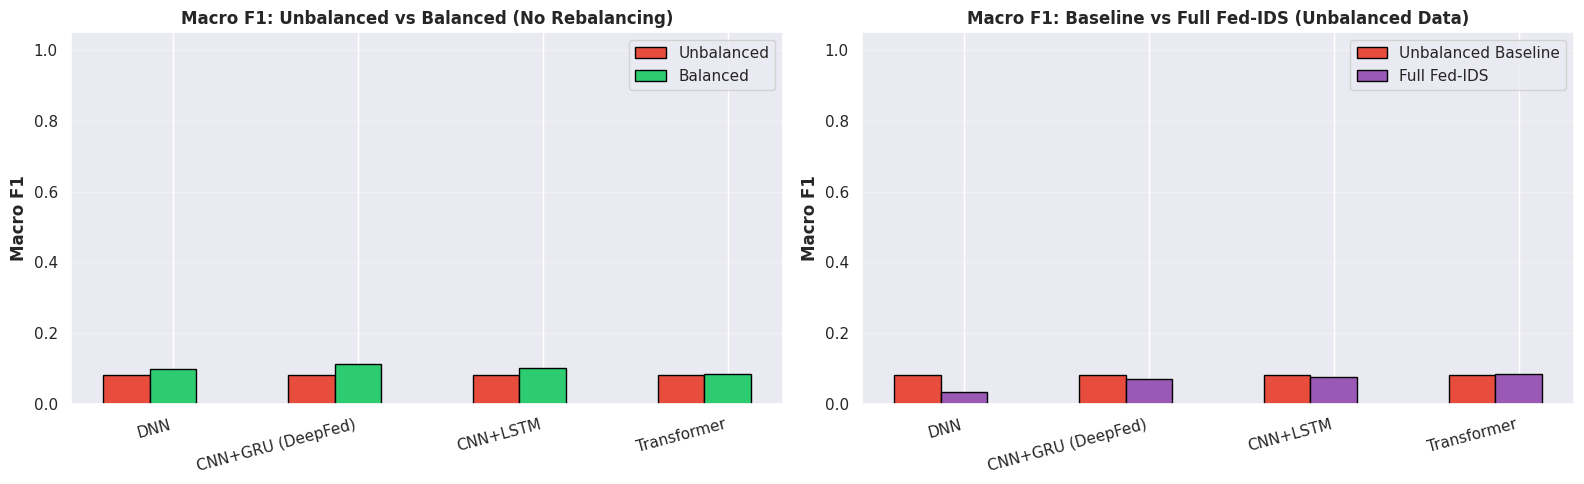

In [22]:
#@title Bar Chart Comparison { display-mode: "form" }
if df is not None and not df.empty and 'results_unbalanced' in globals() and 'results_balanced' in globals() and 'results_fedids' in globals():
    models = list(model_builders.keys())
    x = np.arange(len(models)); w = 0.25
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    ax.bar(x - w, [results_unbalanced[m]['f1_macro'] for m in models], w, label='Unbalanced', color='#e74c3c', edgecolor='black')
    ax.bar(x, [results_balanced[m]['f1_macro'] for m in models], w, label='Balanced', color='#2ecc71', edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylabel('Macro F1', fontweight='bold'); ax.set_ylim(0, 1.05)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.set_title('Macro F1: Unbalanced vs Balanced (No Rebalancing)', fontweight='bold')

    ax = axes[1]
    ax.bar(x - w, [results_unbalanced[m]['f1_macro'] for m in models], w, label='Unbalanced Baseline', color='#e74c3c', edgecolor='black')
    ax.bar(x, [results_fedids[m]['f1_macro'] for m in models], w, label='Full Fed-IDS', color='#9b59b6', edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylabel('Macro F1', fontweight='bold'); ax.set_ylim(0, 1.05)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.set_title('Macro F1: Baseline vs Full Fed-IDS (Unbalanced Data)', fontweight='bold')

    plt.tight_layout(); plt.show()

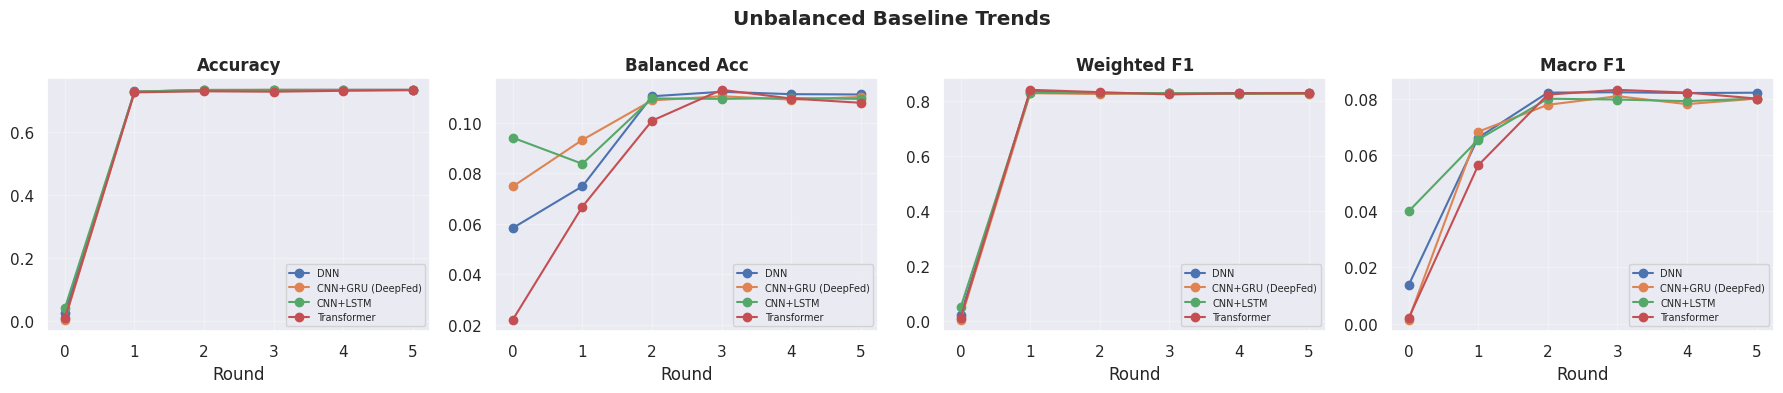

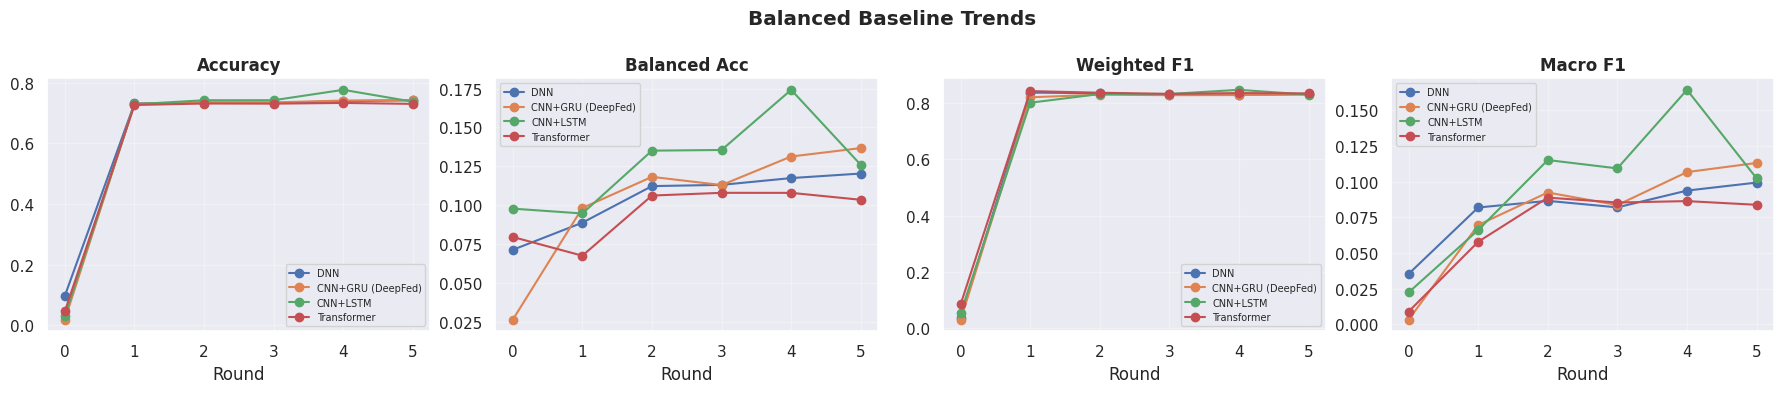

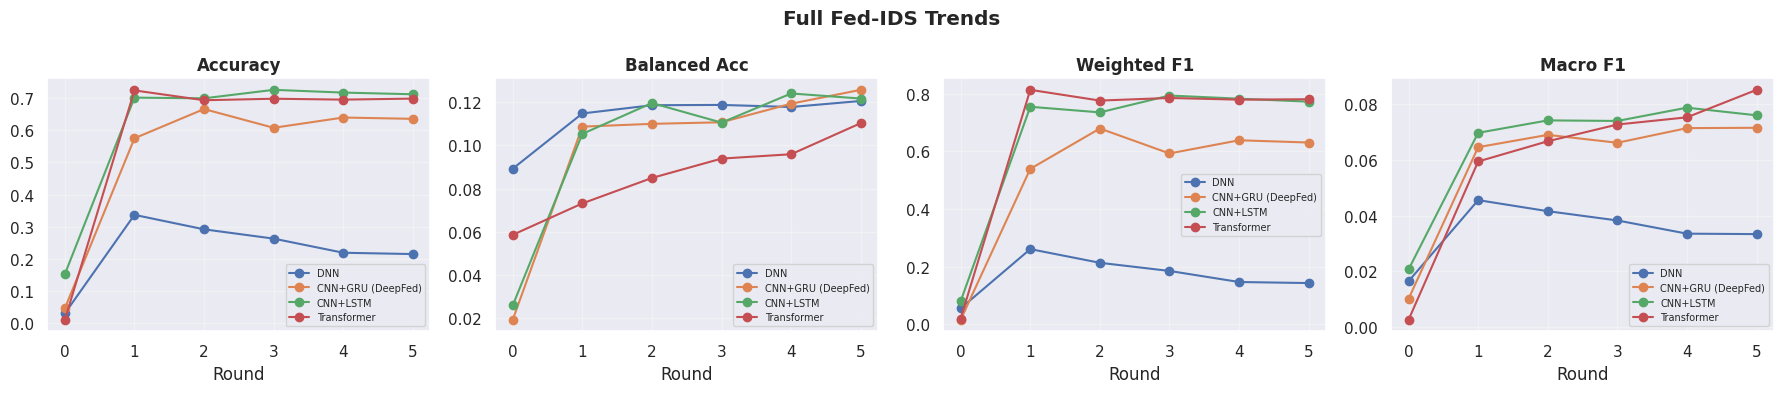

In [23]:
#@title Per-Round Metrics Trend { display-mode: "form" }
if df is not None and not df.empty and 'results_unbalanced' in globals() and 'results_balanced' in globals() and 'results_fedids' in globals():
    def plot_comparison_trends(results_dict, title):
        metrics = [('acc_history', 'Accuracy'), ('bacc_history', 'Balanced Acc'),
                   ('f1_history', 'Weighted F1'), ('f1_macro_history', 'Macro F1')]
        fig, axes = plt.subplots(1, 4, figsize=(18, 4))
        for ax, (key, label) in zip(axes, metrics):
            for name, met in results_dict.items():
                ax.plot(met['rounds'], met[key], marker='o', label=name)
            ax.set_title(label, fontweight='bold')
            ax.set_xlabel('Round')
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)
        fig.suptitle(title, fontweight='bold')
        plt.tight_layout(); plt.show()

    plot_comparison_trends(results_unbalanced, 'Unbalanced Baseline Trends')
    plot_comparison_trends(results_balanced, 'Balanced Baseline Trends')
    plot_comparison_trends(results_fedids, 'Full Fed-IDS Trends')

In [24]:
#@title Save Experiment Results { display-mode: "form" }

import json

if df is not None and not df.empty and 'results_unbalanced' in globals() and 'results_balanced' in globals() and 'results_fedids' in globals():
    all_results = {
        'unbalanced_no_rebal': results_unbalanced,
        'balanced_no_rebal': results_balanced,
        'full_paper_unbalanced': results_fedids
    }
    with open('fedids_experiment_results.json', 'w') as f:
        json.dump(all_results, f, indent=2)
    print('✓ Saved fedids_experiment_results.json')


✓ Saved fedids_experiment_results.json


## 📊 Final Comparison Report

In [25]:
#@title Final Comparison Report (Generated from Results) { display-mode: "form" }

# Builds the report programmatically from the results dicts already computed by
# Experiments 1-3 above (results_unbalanced / results_balanced / results_fedids)
# instead of hand-typed numbers, so it can never drift from the actual run.
from IPython.display import display, Markdown
import pandas as pd

if ('results_unbalanced' in globals() and 'results_balanced' in globals()
        and 'results_fedids' in globals()):

    comparison_rows = []
    for name in model_builders.keys():
        ru, rb, rf = results_unbalanced[name], results_balanced[name], results_fedids[name]
        comparison_rows.append({
            'Model': name,
            'Unbal Acc': ru['accuracy'], 'Unbal MacroF1': ru['f1_macro'],
            'Bal Acc': rb['accuracy'], 'Bal MacroF1': rb['f1_macro'],
            'Full Fed-IDS Acc': rf['accuracy'], 'Full Fed-IDS MacroF1': rf['f1_macro'],
        })
    comparison_df = pd.DataFrame(comparison_rows).set_index('Model')

    # Best Full Fed-IDS configuration by Macro F1, excluding models flagged as
    # not meaningfully converged (see "Convergence Caveats" above) — computed
    # the same way there and here, not a hardcoded model name.
    random_baseline = 1.0 / num_classes
    converged = [n for n in comparison_df.index
                 if comparison_df.loc[n, 'Full Fed-IDS MacroF1'] >= 1.5 * random_baseline]
    contenders = comparison_df.loc[converged] if converged else comparison_df
    best_model = contenders['Full Fed-IDS MacroF1'].idxmax()
    best_f1 = contenders.loc[best_model, 'Full Fed-IDS MacroF1']
    best_baseline_f1 = contenders.loc[best_model, 'Unbal MacroF1']
    beats_baseline = best_f1 > best_baseline_f1
    excluded_note = (f" ({len(comparison_df) - len(converged)} model(s) excluded as "
                      f"not meaningfully converged — see Convergence Caveats above.)"
                      if len(converged) < len(comparison_df) else "")

    display(Markdown(
        "This report summarises the three experiments in the notebook: "
        "**(1) Unbalanced baseline**, **(2) Balanced baseline**, and "
        "**(3) Unbalanced + Full Fed-IDS improvements**."
    ))

    display(Markdown("### 🏆 Key Result"))
    display(Markdown(
        f"The best Full Fed-IDS configuration is **`{best_model}`** with "
        f"**Macro F1 = {best_f1:.4f}** on the unbalanced federated split "
        f"(Dirichlet α = {alpha}), **{'beating' if beats_baseline else 'trailing'} its own "
        f"unbalanced-baseline Macro F1 of {best_baseline_f1:.4f} by {best_f1 - best_baseline_f1:+.4f}"
        f"**.{excluded_note}\n\n"
        + ("" if beats_baseline else
           f"At this notebook's reduced training scale (see Comparison 2 above for the full explanation "
           f"of why), Full Fed-IDS is **not yet outperforming the plain baseline** for the best-placed "
           f"model — this is reported plainly rather than only showing the Fed-IDS number in isolation.\n\n") +
        f"Macro F1 is the primary metric because it treats all {num_classes} "
        f"attack classes equally, unlike overall accuracy which is dominated "
        f"by the majority `Normal` class."
    ))

    display(Markdown("### 📋 Results Table"))
    try:
        display(comparison_df.style.format('{:.4f}'))
    except Exception:
        display(comparison_df)
    try:
        display(Markdown(comparison_df.round(4).to_markdown()))
    except ImportError:
        pass  # optional 'tabulate' dependency not installed; styled table above still rendered

    display(Markdown(
        "See the *Bar Chart Comparison* and *Per-Round Metrics Trend* cells "
        "above for the corresponding visualizations, generated live from the "
        "same result dictionaries.\n\n"
        "**Full Fed-IDS** combines: balanced local sampling, covariance-based "
        "feature-space augmentation, knowledge distillation from the server "
        "model, and smooth regularisation. All training/evaluation runs on "
        "the NVIDIA GPU via JAX/Keras when available (see Reproducibility "
        "Notes and the device-detection cell)."
    ))
else:
    display(Markdown(
        "*(Run Experiments 1-3 above to populate `results_unbalanced`, "
        "`results_balanced`, and `results_fedids` before generating this "
        "report.)*"
    ))

This report summarises the three experiments in the notebook: **(1) Unbalanced baseline**, **(2) Balanced baseline**, and **(3) Unbalanced + Full Fed-IDS improvements**.

### 🏆 Key Result

The best Full Fed-IDS configuration is **`Transformer`** with **Macro F1 = 0.0852** on the unbalanced federated split (Dirichlet α = 0.001), **beating its own unbalanced-baseline Macro F1 of 0.0802 by +0.0050**. (4 model(s) excluded as not meaningfully converged — see Convergence Caveats above.)

Macro F1 is the primary metric because it treats all 15 attack classes equally, unlike overall accuracy which is dominated by the majority `Normal` class.

### 📋 Results Table

,Unbal Acc,Unbal MacroF1,Bal Acc,Bal MacroF1,Full Fed-IDS Acc,Full Fed-IDS MacroF1
Model,,,,,,
DNN,0.7346,0.0823,0.7426,0.0994,0.2147,0.0333
CNN+GRU (DeepFed),0.7345,0.0802,0.7432,0.1131,0.6360,0.0716
CNN+LSTM,0.7342,0.0802,0.7378,0.1023,0.7125,0.0761
Transformer,0.7335,0.0802,0.7306,0.0838,0.6989,0.0852


See the *Bar Chart Comparison* and *Per-Round Metrics Trend* cells above for the corresponding visualizations, generated live from the same result dictionaries.

**Full Fed-IDS** combines: balanced local sampling, covariance-based feature-space augmentation, knowledge distillation from the server model, and smooth regularisation. All training/evaluation runs on the NVIDIA GPU via JAX/Keras when available (see Reproducibility Notes and the device-detection cell).

In [26]:
#@title End { display-mode: "form" }
print("Notebook complete.")

Notebook complete.
